In [1]:
# Installing necessary libraries
!pip install gymnasium
!pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [2]:
from google.colab import drive

drive.mount('/content/drive') # Loading Drive

Mounted at /content/drive


In [3]:
# Loading all libraries
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [4]:
rye_microgrid_data = pd.read_csv('train.csv') # Load the dataset
rye_microgrid_data

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.0,0.0,1.0,10.0,64826.0,...,8.4,60.7,1.3,8.4,246.3,8.3,60.3,1.0,10.4,247.3
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.0,0.0,1.0,0.0,8961.1,...,8.4,61.6,1.5,8.0,252.3,8.4,60.7,1.2,10.0,252.1
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.0,0.0,1.0,0.0,0.0,...,8.5,60.3,1.3,9.6,254.1,8.4,59.6,1.0,11.7,253.8
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.0,0.0,1.0,0.0,0.0,...,8.4,63.9,2.0,12.1,254.6,8.3,63.4,1.7,14.3,254.2
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.0,0.0,1.0,0.0,0.0,...,7.2,78.9,3.8,11.7,249.5,7.1,77.9,3.5,13.9,249.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9510,2021-01-31 19:00:00,0.0,21.98,44.422658,0.60243,0.0,0.0,1.0,0.0,0.0,...,-3.2,93.1,-4.2,4.8,231.2,-3.1,91.6,-4.3,6.0,238.3
9511,2021-01-31 20:00:00,0.0,9.60,45.167707,0.53335,0.0,0.0,1.0,0.0,0.0,...,-3.5,94.1,-4.3,4.9,224.9,-3.3,92.1,-4.4,6.2,231.8
9512,2021-01-31 21:00:00,0.0,22.61,32.476198,0.51195,0.0,0.0,1.0,0.0,0.0,...,-3.6,93.0,-4.6,4.7,224.5,-3.3,90.6,-4.6,6.0,231.7
9513,2021-01-31 22:00:00,0.0,21.70,28.561791,0.47122,0.0,0.0,1.0,0.0,0.0,...,-3.7,92.1,-4.8,4.5,222.8,-3.4,89.5,-4.9,5.8,231.1


In [5]:
rye_microgrid_data.columns

Index(['time', 'pv_production', 'wind_production', 'consumption',
       'spot_market_price', 'precip_1h:mm', 'precip_type:idx',
       'prob_precip_1h:p', 'clear_sky_rad:W', 'clear_sky_energy_1h:J',
       'diffuse_rad:W', 'diffuse_rad_1h:Wh', 'direct_rad:W',
       'direct_rad_1h:Wh', 'global_rad:W', 'global_rad_1h:Wh',
       'sunshine_duration_1h:min', 'sun_azimuth:d', 'sun_elevation:d',
       'low_cloud_cover:p', 'medium_cloud_cover:p', 'high_cloud_cover:p',
       'total_cloud_cover:p', 'effective_cloud_cover:p', 'temp',
       'relative_humidity_2m:p', 'dew_point_2m:C', 'wind_speed_2m:ms',
       'wind_dir_2m:d', 't_10m:C', 'relative_humidity_10m:p',
       'dew_point_10m:C', 'wind_speed_10m:ms', 'wind_dir_10m:d', 't_50m:C',
       'relative_humidity_50m:p', 'dew_point_50m:C', 'wind_speed_50m:ms',
       'wind_dir_50m:d', 't_100m:C', 'relative_humidity_100m:p',
       'dew_point_100m:C', 'wind_speed_100m:ms', 'wind_dir_100m:d'],
      dtype='object')

The following are the states allowed for each of the grid components:

**Renewable:** \
           0- Store in Battery only \
           1- Use for Load/Battery \
           2- Sell to Grid \
**Battery:** \
         0- Charge/Idle State \
         1- Use for Load \
         2- Sell to Grid \
**Grid:** \
      0 - Disconnect \
      1- Connect (to Buy) \
      2- Connect (to Sell) \

**Legal Combinations allowed for the microgrid:** \
001, 100, 101, 110, 111, 122, 212

**Combined Actions:** \
Action 0- Renewable Charges Battery + Grid Connected to satisfy load \
Action 1- Renewable Satisfies Load + Battery Charging + Grid Disconnected \
Action 2- Renewable Satisfies Load + Battery Charging + Grid Connected \
Action 3- Renewable and Battery Satisfy Load + Grid Disconnected \
Action 4- Renewable and Battery Satisfy Load + Grid Connected \
Action 5- Renewable Satisfies Load + Battery sells excess to Grid
Action 6- Renewable Sells to Grid + Battery satisfies Load

Environment without Forecasting

In [ ]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class RyeMicrogridEnv(gym.Env):
  """
    Custom Microgrid Environment for Rye Microgrid
  """
  def __init__(self, data, num_days):
    super(RyeMicrogridEnv, self).__init__()
    # no of hours to simulate
    self.num_hours = 24 * num_days
    self.curr_hour = 0

    # store all necessary data for Rye Microgrid
    self.data = data

    # setup battery
    self.battery_max = 500
    self.battery_power = 0.5 * self.battery_max # starting at 50%
    self.charge_efficiency = 0.85 # how much power is actually drawn/stored (accounts for losses due to transmission)

    # State consists of PV, Wind, Battery, Load and Price
    self.observation_space = spaces.Box(
        low=np.array([0, 0, 0, 0, 0], dtype=np.float32),
        high=np.array([80, 230, self.battery_max, 100, 2], dtype=np.float32), # max states taken from description of data
        dtype=np.float32
    )

    # Action Space: 7 Actions described above
    self.action_space = spaces.Discrete(7)

    self.state = self._get_observation()

  def _get_observation(self):
    # Returns the state variables
    curr_data = self.data.loc[self.curr_hour, ['pv_production', 'wind_production', 'consumption', 'spot_market_price']]

    return np.array([curr_data['pv_production'], curr_data['wind_production'], self.battery_power, curr_data['consumption'], curr_data['spot_market_price']], dtype=np.float32)

  def step(self, action):
    # Unpack state
    pv, wind, battery, load, price = self.state

    # Set reward and done states
    reward = 0 # total reward
    reward_buy = 0 # reward for buying from grid
    reward_sell = 0 # reward for selling to grid
    reward_renewable_use = 0 # reward for using renewable energy
    reward_unused_load = 0 # reward for unused load
    reward_grid_conn = 0 # reward for connecting/disconnecting to grid
    reward_buy_factor = 1 # buy factor
    reward_sell_factor = 0.6 # sell factor
    reward_renewable_use_factor = 0.8 # factor for using renewable energy
    reward_unused_load_factor = 100 # factor for unused load
    reward_grid_conn_factor = 0.5 # grid connection factor

    done = False # done state

    # Parameters to help visualization
    consumption = load
    unmet = 0
    purchased = 0
    sold = 0


    # Action Handling
    if action == 0: # Use Renewable to charge battery & buy from grid to satisfy load
      self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind))
      purchased = consumption
      unmet = 0 # all energy purchased from grid
      reward_buy -= purchased * price
      reward_grid_conn -= 5
      reward_renewable_use += (pv + wind) * price
    elif action == 1: # Use Renewable for Load while Battery is also charging and Grid is disconnected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_grid_conn += 5
        reward_renewable_use += (pv + wind) * price
        purchased = 0
        self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind - consumption))
      else:
        unmet = consumption - pv - wind
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn += 5
        reward_unused_load -= unmet * price
    elif action == 2: # Use Renewable for Load while Battery is charging and Grid is connected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn -= 5
        purchased = 0
        self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind - consumption))
      else:
        unmet = 0
        reward_renewable_use += (pv + wind) * price
        purchased = consumption - pv - wind
        reward_buy -= (consumption - pv - wind) * price
        reward_grid_conn -= 5
    elif action == 3: # Use both Battery & Renewable for Load while grid is disconnected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn += 5
        purchased = 0
      else:
        if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv - wind):
          unmet = 0
          purchased = 0
          self.battery_power -= (consumption - pv - wind)/self.charge_efficiency
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn += 5
        else:
          unmet = consumption - pv - wind - self.battery_power
          self.battery_power = 0
          purchased = 0
          reward_renewable_use += (pv + wind) * price
          reward_unused_load -= unmet * price
          reward_grid_conn += 5
    elif action == 4: # Use both Battery & Renewable for Load while grid is connected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn -= 5
        purchased = 0
      else:
        if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv - wind):
          unmet = 0
          purchased = 0
          self.battery_power -= (consumption - pv - wind) / self.charge_efficiency
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn -= 5
        else:
          unmet = 0
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn -= 5
          purchased = consumption - pv - wind
          reward_buy -= purchased * price
    elif action == 5: # Use Renewable for Load and Battery to sell to Grid
      if pv + wind >= consumption:
        unmet = 0
        sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
        self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
        reward_sell += sold * price
        reward_grid_conn -= 5
        reward_renewable_use += (pv + wind) * price
      else:
        unmet = consumption - pv - wind
        sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
        self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
        reward_sell += sold * price
        reward_renewable_use += (pv + wind) * price
        reward_unused_load -= unmet * price
        reward_grid_conn -= 5
    elif action == 6: # Use Renewable to sell and Battery to load
      if self.battery_power >= consumption / self.charge_efficiency:
        unmet = 0
        sold = pv + wind
        self.battery_power -= consumption / self.charge_efficiency
        reward_sell += sold * price
        reward_grid_conn -= 5
      else:
        unmet = consumption - self.charge_efficiency * self.battery_power
        self.battery_power = 0
        sold = pv + wind
        reward_sell += sold * price
        reward_grid_conn -= 5
        reward_unused_load -= unmet * price

    # Update state
    self.curr_hour += 1
    if self.curr_hour >= self.num_hours:
        done = True

    # Calculate reward
    reward += reward_sell * reward_sell_factor + reward_unused_load * reward_unused_load_factor \
              + reward_grid_conn * reward_grid_conn_factor + reward_renewable_use * reward_renewable_use_factor \
              + reward_buy * reward_buy_factor
    # Calculate status for grid, battery, and renewable
    grid_status = "Connected"
    battery_status = "Discharge Mode"
    renewable_status = "Satisfy Load and Battery"
    if reward_grid_conn > 0:
      grid_status = "Island Mode"
    if action == 0 or action == 1 or action == 2:
      battery_status = "Charge/Idle Mode"
    if action == 5:
      battery_status = "Discharge Sell Mode"
    if action == 0:
      renewable_status = "Charge Battery only"
    elif action == 6:
      renewable_status = "Sell to Grid"

    # Update state
    self.state = self._get_observation()
    return self.state, reward, done, False, {
        "sold": sold,
        "unmet": unmet,
        "purchased": purchased,
        "battery": self.battery_power,
        "price": price,
        "load": load,
        "pv": pv,
        "wind": wind,
        "action": action,
        "hour": self.curr_hour,
        "grid_status": grid_status,
        "renewable_status": renewable_status,
        "battery_status": battery_status
    }

  def reset(self, seed=None, options=None):
    # Reset important parameters
    super().reset(seed=seed)
    self.curr_hour = 0
    self.battery_power = 0.5 * self.battery_max
    self.state = self._get_observation()
    return self.state, {}


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Create and wrap environment
env = RyeMicrogridEnv(rye_microgrid_data, num_days=365)
vec_env = make_vec_env(lambda: env, n_envs=1)

# Train the PPO agent
model = PPO("MlpPolicy", vec_env, verbose=1)
model.learn(total_timesteps=1000000)


# Save the model
model.save("ppo_microgrid_initial")

Using cuda device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
|    value_loss           | 2.7e+03      |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 8.76e+03     |
|    ep_rew_mean          | -1.16e+04    |
| time/                   |              |
|    fps                  | 362          |
|    iterations           | 252          |
|    time_elapsed         | 1423         |
|    total_timesteps      | 516096       |
| train/                  |              |
|    approx_kl            | 0.0021982377 |
|    clip_fraction        | 0.0116       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.423       |
|    explained_variance   | 0.603        |
|    learning_rate        | 0.0003       |
|    loss                 | 715          |
|    n_updates            | 2510         |
|    policy_gradient_loss | -0.00193     |
|    value_loss           | 1.16e+03     |
---

In [ ]:
# Helper Function to simulate and plot on test set
def simulate_and_plot(env, model, num_days_to_visualize=2):
    state, _ = env.reset()
    done = False

    log = {
        "hour": [],
        "action": [],
        "sold": [],
        "unmet": [],
        "purchased": [],
        "battery": [],
        "price": [],
        "load": [],
        "pv": [],
        "wind": [],
        "reward": [],
        "battery_status": [],
        "grid_status": [],
        "renewable_status": []
    }

    steps_to_visualize = 24 * num_days_to_visualize

    for _ in range(steps_to_visualize):
        action, _ = model.predict(state, deterministic=True)
        next_state, reward, done, _, info = env.step(action)

        for key in log:
            if key == "reward":
                log["reward"].append(reward)
            else:
                log[key].append(info[key])

        state = next_state
        if done:
            break

    hours = list(range(len(log["action"])))
    plt.figure(figsize=(14, 16))

    plt.subplot(4, 1, 1)
    plt.plot(hours, log["action"], label="Action", marker='o')
    plt.title("Actions Taken Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Action ID")
    plt.grid(True)
    plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(hours, log["sold"], label="Sold to Grid")
    plt.plot(hours, log["purchased"], label="Purchased from Grid")
    plt.plot(hours, log["unmet"], label="Unmet Load")
    plt.plot(hours, log["reward"], label="Reward", linestyle='--', color='black')
    plt.title("Grid Interaction and Reward")
    plt.xlabel("Hour")
    plt.ylabel("Energy / Reward")
    plt.grid(True)
    plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(hours, log["pv"], label="PV Production")
    plt.plot(hours, log["wind"], label="Wind Production")
    plt.plot(hours, log["load"], label="Load")
    plt.plot(hours, log["battery"], label="Battery Level")
    plt.plot(hours, log["price"], label="Spot Market Price", linestyle='--')
    plt.title("State Variables Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    battery_status_map = {
        "Charge/Idle Mode": 0,
        "Discharge Mode": 1,
        "Discharge Sell Mode": 2
    }
    grid_status_map = {
        "Connected": 0,
        "Island Mode": 1
    }
    renewable_status_map = {
        "Satisfy Load and Battery": 0,
        "Charge Battery only": 1,
        "Sell to Grid": 2
    }

    battery_status_vals = [battery_status_map.get(s, -1) for s in log["battery_status"]]
    grid_status_vals = [grid_status_map.get(s, -1) for s in log["grid_status"]]
    renewable_status_vals = [renewable_status_map.get(s, -1) for s in log["renewable_status"]]

    plt.figure(figsize=(14, 10))
    plt.subplot(3, 1, 1)
    plt.plot(hours, battery_status_vals, label="Battery Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Charge/Idle Mode", "Discharge Mode", "Discharge Sell Mode"])
    plt.title("Battery Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(hours, grid_status_vals, label="Grid Status", drawstyle='steps-post')
    plt.yticks([0, 1], ["Connected", "Island Mode"])
    plt.title("Grid Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(hours, renewable_status_vals, label="Renewable Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Satisfy Load and Battery", "Charge Battery only", "Sell to Grid"])
    plt.title("Renewable Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


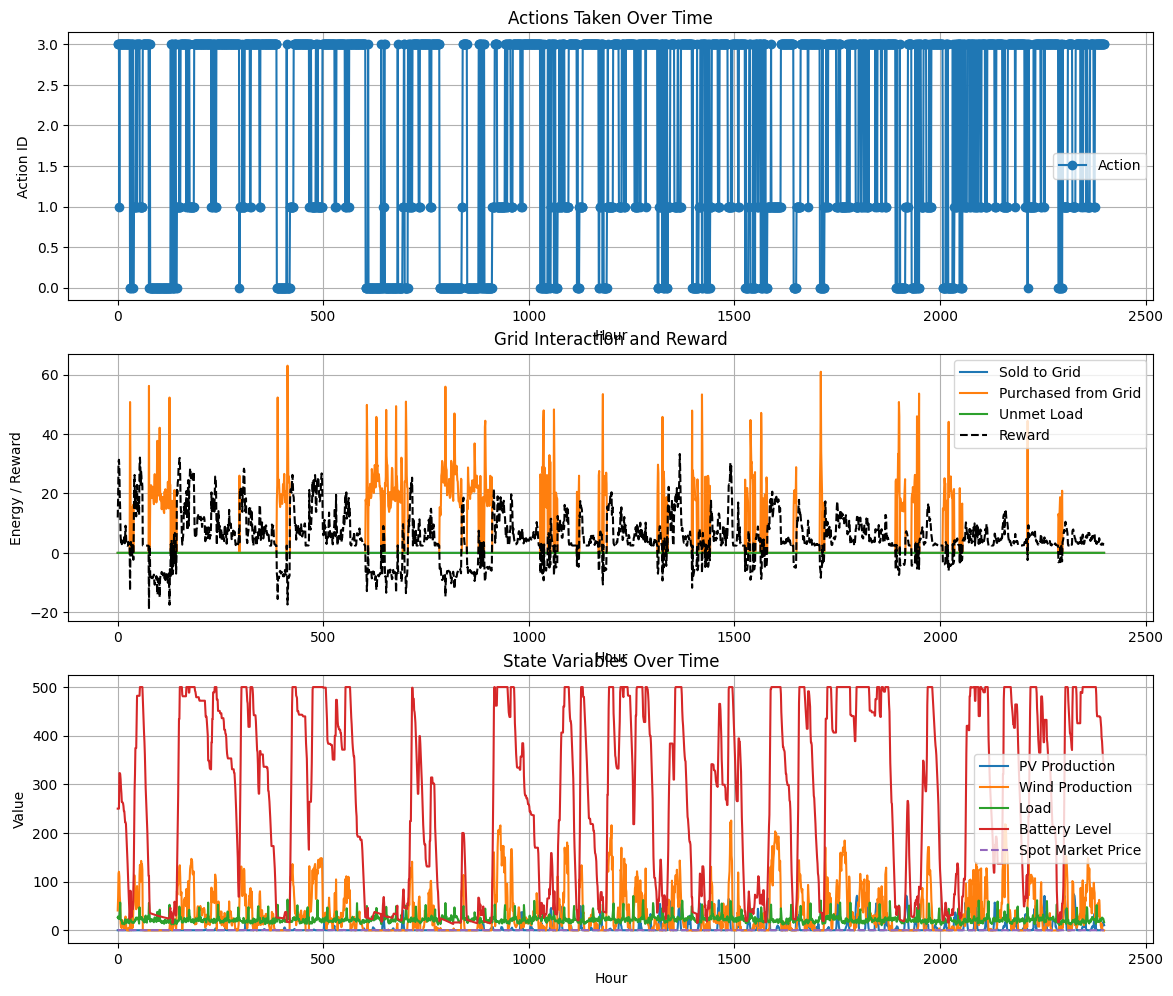

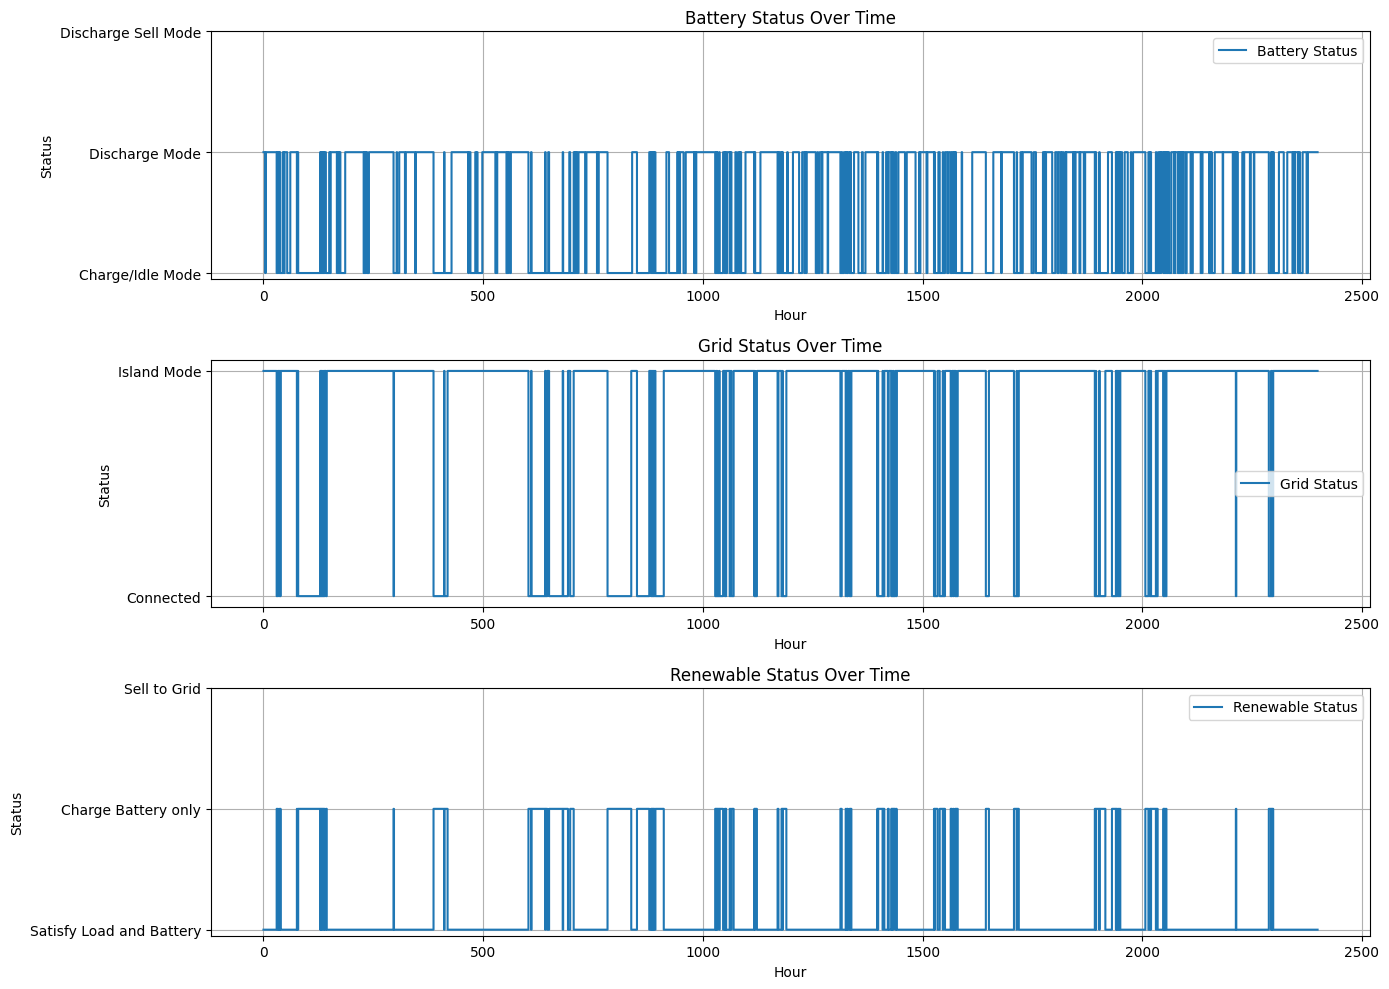

In [ ]:
simulate_and_plot(env, model, num_days_to_visualize=100)

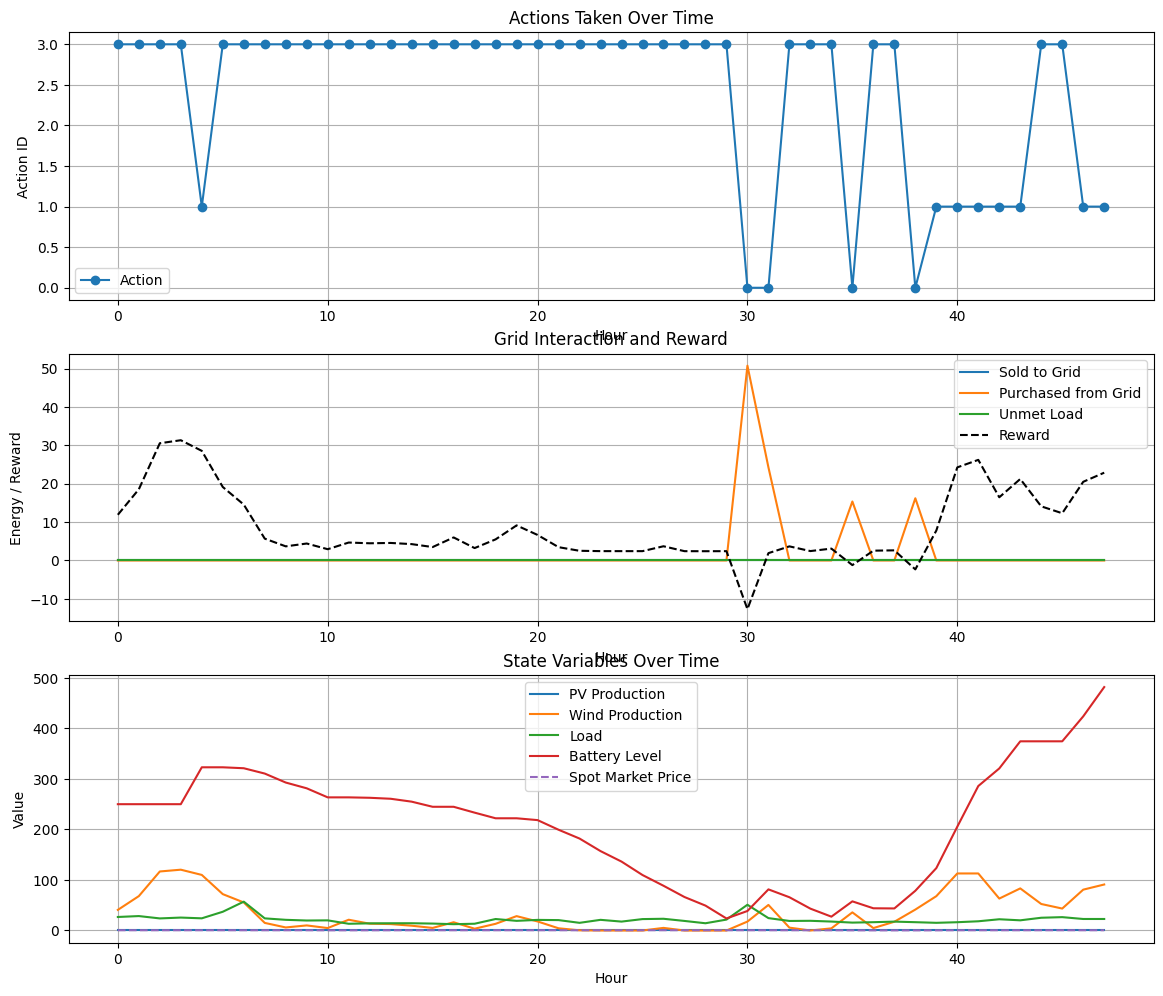

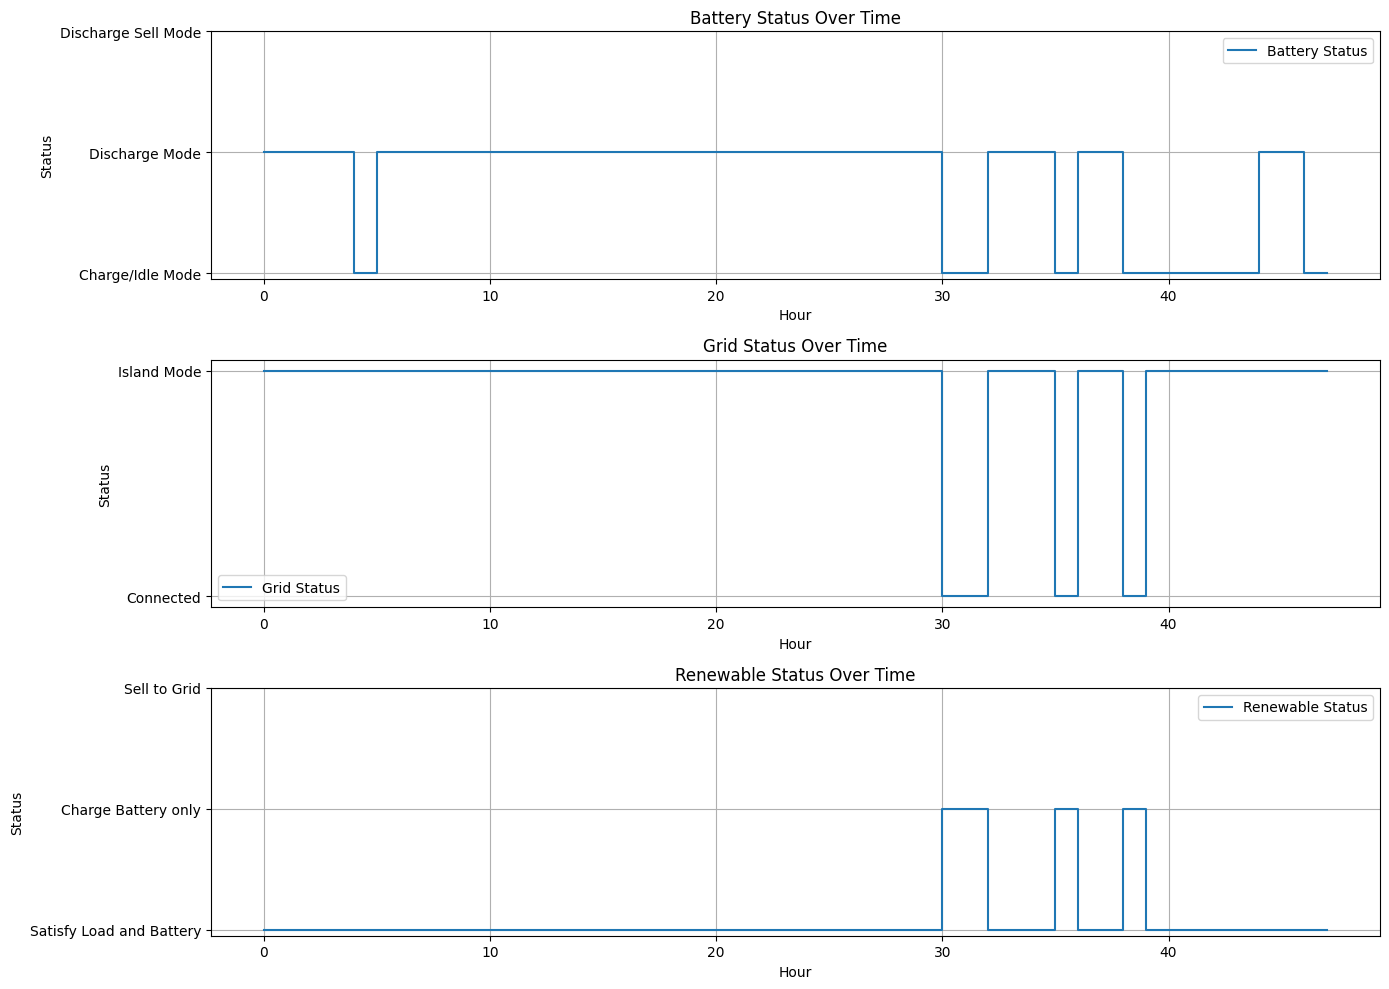

In [ ]:
simulate_and_plot(env, model, num_days_to_visualize=2)

Creating Test Set and Evaluating

In [ ]:
rye_test = pd.read_csv('test.csv')
rye_test

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2021-02-01 00:00:00,0.0,29.02,37.731253,0.42572,0.0,0.0,1.0,0.0,0.0,...,-4.3,91.9,-5.4,4.0,213.8,-3.7,88.8,-5.3,5.1,223.2
1,2021-02-01 01:00:00,0.0,27.09,39.288933,0.42531,0.0,0.0,1.0,0.0,0.0,...,-4.6,91.5,-5.8,4.0,205.6,-4.0,87.8,-5.7,5.1,214.8
2,2021-02-01 02:00:00,0.0,40.56,37.472487,0.41575,0.0,0.0,1.0,0.0,0.0,...,-4.9,91.2,-6.1,4.3,203.8,-4.1,86.9,-5.9,5.6,212.1
3,2021-02-01 03:00:00,0.0,37.72,37.343327,0.42344,0.0,0.0,1.0,0.0,0.0,...,-5.2,89.9,-6.6,4.3,201.7,-4.3,85.0,-6.4,5.6,210.4
4,2021-02-01 04:00:00,0.0,47.98,38.386463,0.50187,0.0,0.0,1.0,0.0,0.0,...,-5.6,88.3,-7.2,4.0,194.6,-4.5,82.4,-7.0,5.0,201.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,2021-03-07 20:00:00,0.0,-0.36,45.174683,0.28008,0.0,0.0,1.0,0.0,0.0,...,-1.2,86.0,-3.2,4.5,268.9,-1.5,86.1,-3.5,5.4,274.8
837,2021-03-07 21:00:00,0.0,4.20,42.956577,0.28772,0.0,0.0,1.0,0.0,0.0,...,-1.4,86.5,-3.4,4.1,260.6,-1.7,86.1,-3.7,5.0,266.6
838,2021-03-07 22:00:00,0.0,13.24,33.505287,0.28761,0.0,0.0,1.0,0.0,0.0,...,-1.9,86.5,-3.8,3.8,252.3,-2.1,85.5,-4.2,4.7,258.2
839,2021-03-07 23:00:00,0.0,23.88,30.679047,0.27743,0.0,0.0,1.0,0.0,0.0,...,-2.5,88.4,-4.1,3.7,236.9,-2.7,87.1,-4.5,4.7,244.9


In [ ]:
rye_test.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,8.410000e+02,841.000000,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,4.510592,20.086468,44.285889,0.404042,0.030666,0.019025,2.037812,48.115339,1.731789e+05,18.186326,...,-2.948989,77.081332,-6.583115,4.394530,189.633294,-2.668847,74.462663,-6.831986,5.215696,193.220690
std,9.632409,27.797933,12.727659,0.175913,0.262185,0.181579,7.707197,83.383694,2.981970e+05,30.160481,...,7.035947,13.169365,7.295046,2.422163,64.746351,6.789937,14.480448,7.243487,2.917581,64.183272
min,0.000000,-0.850000,21.420865,0.165030,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-17.100000,40.900000,-21.000000,0.600000,17.600000,-17.000000,32.200000,-21.700000,0.100000,17.800000
25%,0.000000,-0.260000,34.778583,0.278580,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-9.300000,68.500000,-14.100000,2.400000,137.900000,-8.400000,66.800000,-14.100000,2.700000,148.500000
50%,0.000000,9.440000,42.102347,0.396150,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-1.400000,79.300000,-6.200000,4.000000,178.400000,-1.700000,76.300000,-6.400000,4.800000,180.000000
75%,2.946333,30.890000,52.058330,0.456690,0.000000,0.000000,1.000000,75.000000,2.603562e+05,32.600000,...,3.300000,87.400000,0.800000,5.700000,244.600000,3.400000,85.200000,0.500000,6.900000,248.300000
max,51.827334,195.570000,111.059900,2.077080,4.660000,3.000000,95.000000,339.700000,1.232206e+06,128.400000,...,10.300000,100.000000,5.200000,13.900000,344.300000,10.200000,100.000000,4.800000,15.700000,345.800000


In [ ]:
rye_microgrid_data.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9.515000e+03,9515.000000,...,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.00000,9515.000000
mean,7.654312,21.254382,20.262091,0.127386,0.066322,0.039096,3.312181,144.807325,5.213013e+05,38.549511,...,5.729207,76.279443,1.591088,4.283847,195.021703,5.633558,74.844782,1.220410,5.11671,198.633568
std,15.673519,38.225468,8.311275,0.125292,0.353434,0.239879,10.585675,232.985222,8.366789e+05,59.636149,...,6.927206,13.792720,6.265550,2.241726,81.361187,6.836455,14.001831,6.255477,2.67242,81.089361
min,0.000000,-582.200000,0.048396,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-14.800000,23.400000,-16.300000,0.100000,0.100000,-14.600000,22.300000,-16.600000,0.10000,0.300000
25%,0.000000,-0.260000,14.757704,0.044375,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,1.200000,67.400000,-2.700000,2.500000,134.100000,1.000000,65.900000,-3.100000,3.00000,142.950000
50%,0.000000,2.370000,18.817098,0.090390,0.000000,0.000000,1.000000,0.000000,3.637200e+03,0.000000,...,4.600000,78.400000,1.200000,4.000000,190.400000,4.500000,76.800000,0.900000,4.90000,192.300000
75%,6.411375,26.040000,23.716080,0.165970,0.000000,0.000000,1.000000,220.800000,7.768631e+05,63.900000,...,10.200000,87.100000,6.400000,5.600000,265.500000,10.100000,85.700000,6.000000,6.70000,267.700000
max,79.855834,225.500000,70.366622,1.140590,6.220000,3.000000,95.000000,834.800000,3.004661e+06,320.200000,...,29.700000,100.000000,17.000000,15.300000,359.900000,29.600000,100.000000,16.500000,17.40000,359.700000


In [ ]:
# Extracting specific month and days from the train
# Ensure 'time' is in datetime format
df1 = rye_test.copy()
df2 = rye_microgrid_data.copy()
df1['time'] = pd.to_datetime(df1['time'])
df2['time'] = pd.to_datetime(df2['time'])

# Create common key based on month, day, hour, and minute
df1['match_key'] = df1['time'].dt.strftime('%m-%d %H:%M')
df2['match_key'] = df2['time'].dt.strftime('%m-%d %H:%M')

# Filter df2 to rows that match df1's timestamps (ignoring year)
df2_matched = df2[df2['match_key'].isin(df1['match_key'])]

# Drop the helper column
df1.drop(columns='match_key', inplace=True)
df2_matched.drop(columns='match_key', inplace=True)
rye_train_rel = df2_matched.reset_index(drop=True)

<ipython-input-21-abbba3c7009f>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_matched.drop(columns='match_key', inplace=True)


In [ ]:
rye_train_rel

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2020-02-01 00:00:00,0.0,24.45,18.009981,0.15487,0.00,0.0,1.0,0.0,0.0,...,1.6,70.4,-3.2,4.2,153.3,1.4,68.0,-3.8,5.7,161.3
1,2020-02-01 01:00:00,0.0,57.05,18.958709,0.15477,0.00,0.0,1.0,0.0,0.0,...,2.0,71.1,-2.7,3.9,130.4,1.8,68.1,-3.4,4.8,145.3
2,2020-02-01 02:00:00,0.0,68.15,18.440980,0.15640,0.00,0.0,1.0,0.0,0.0,...,2.0,68.0,-3.3,4.2,151.3,1.8,66.1,-3.9,5.5,161.6
3,2020-02-01 03:00:00,0.0,69.37,17.492381,0.15853,0.00,0.0,1.0,0.0,0.0,...,1.9,68.7,-3.2,3.7,149.0,1.7,67.1,-3.8,4.9,162.3
4,2020-02-01 04:00:00,0.0,42.16,16.040638,0.16108,0.00,0.0,1.0,0.0,0.0,...,1.6,74.7,-2.4,4.1,136.7,1.3,73.4,-2.9,5.1,151.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,2020-03-07 20:00:00,0.0,145.28,21.321811,0.13620,0.00,0.0,1.0,0.0,0.0,...,-0.8,64.1,-6.7,5.1,150.8,-1.0,62.1,-7.3,6.8,159.9
837,2020-03-07 21:00:00,0.0,173.14,21.645391,0.13065,0.00,0.0,1.0,0.0,0.0,...,-0.4,63.0,-6.6,5.5,149.0,-0.6,61.1,-7.2,7.2,159.3
838,2020-03-07 22:00:00,0.0,92.00,21.720153,0.12562,0.17,3.0,8.5,0.0,0.0,...,-0.1,62.9,-6.3,5.9,154.7,-0.2,61.4,-6.8,7.7,162.9
839,2020-03-07 23:00:00,0.0,127.03,22.942129,0.10856,1.67,3.0,71.4,0.0,0.0,...,0.1,64.5,-5.8,6.2,155.1,-0.1,63.2,-6.3,8.0,164.0


In [ ]:
rye_train_rel.describe()

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,841,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,8.410000e+02,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,2020-02-18 16:49:22.187871744,4.668120,32.991165,23.505811,0.140935,0.050024,0.046373,2.948157,47.141617,1.697069e+05,...,0.087396,76.932461,-3.645541,4.875268,180.494174,0.096790,74.899049,-4.012485,5.975030,186.139477
min,2020-02-01 00:00:00,0.000000,-0.610000,11.426423,0.047250,0.000000,0.000000,1.000000,0.000000,0.000000e+00,...,-8.900000,41.900000,-16.300000,0.300000,7.300000,-8.600000,40.800000,-16.600000,0.200000,13.000000
25%,2020-02-09 18:00:00,0.000000,-0.280000,18.798467,0.112400,0.000000,0.000000,1.000000,0.000000,0.000000e+00,...,-1.500000,67.300000,-5.700000,3.200000,136.200000,-1.500000,64.800000,-6.200000,4.000000,146.200000
50%,2020-02-18 12:00:00,0.000000,11.800000,21.999036,0.141380,0.000000,0.000000,1.000000,0.000000,0.000000e+00,...,0.500000,78.800000,-3.100000,4.400000,180.900000,0.500000,76.200000,-3.400000,5.700000,184.100000
75%,2020-02-27 06:00:00,1.181417,42.780000,25.298744,0.167130,0.000000,0.000000,1.000000,69.700000,2.555562e+05,...,2.200000,86.700000,-0.900000,6.500000,229.100000,2.000000,84.700000,-1.400000,8.000000,238.200000
max,2020-03-08 00:00:00,64.869416,225.500000,70.366622,0.252060,3.080000,3.000000,95.000000,341.300000,1.239120e+06,...,6.900000,99.200000,3.300000,12.300000,336.400000,6.600000,99.800000,3.000000,14.200000,349.200000
std,NaN,12.053125,48.602958,8.057081,0.037952,0.262449,0.318463,9.810515,82.463685,2.949002e+05,...,3.069610,12.585211,3.637943,2.288144,63.399917,2.954218,12.946966,3.688628,2.713857,63.403925


In [ ]:
rye_test.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,8.410000e+02,841.000000,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,4.510592,20.086468,44.285889,0.404042,0.030666,0.019025,2.037812,48.115339,1.731789e+05,18.186326,...,-2.948989,77.081332,-6.583115,4.394530,189.633294,-2.668847,74.462663,-6.831986,5.215696,193.220690
std,9.632409,27.797933,12.727659,0.175913,0.262185,0.181579,7.707197,83.383694,2.981970e+05,30.160481,...,7.035947,13.169365,7.295046,2.422163,64.746351,6.789937,14.480448,7.243487,2.917581,64.183272
min,0.000000,-0.850000,21.420865,0.165030,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-17.100000,40.900000,-21.000000,0.600000,17.600000,-17.000000,32.200000,-21.700000,0.100000,17.800000
25%,0.000000,-0.260000,34.778583,0.278580,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-9.300000,68.500000,-14.100000,2.400000,137.900000,-8.400000,66.800000,-14.100000,2.700000,148.500000
50%,0.000000,9.440000,42.102347,0.396150,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-1.400000,79.300000,-6.200000,4.000000,178.400000,-1.700000,76.300000,-6.400000,4.800000,180.000000
75%,2.946333,30.890000,52.058330,0.456690,0.000000,0.000000,1.000000,75.000000,2.603562e+05,32.600000,...,3.300000,87.400000,0.800000,5.700000,244.600000,3.400000,85.200000,0.500000,6.900000,248.300000
max,51.827334,195.570000,111.059900,2.077080,4.660000,3.000000,95.000000,339.700000,1.232206e+06,128.400000,...,10.300000,100.000000,5.200000,13.900000,344.300000,10.200000,100.000000,4.800000,15.700000,345.800000


In [ ]:
# Columns to scale
cols_to_scale = ['consumption']

# Scale Test's Min/Max to that of Train
scaler = MinMaxScaler()
rye_test[cols_to_scale] = scaler.fit_transform(rye_test[cols_to_scale])
scaler = MinMaxScaler()
scaler.fit(rye_train_rel[cols_to_scale])
rye_test[cols_to_scale] = scaler.inverse_transform(rye_test[cols_to_scale])

In [ ]:
rye_test.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,8.410000e+02,841.000000,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,4.510592,20.086468,26.460823,0.404042,0.030666,0.019025,2.037812,48.115339,1.731789e+05,18.186326,...,-2.948989,77.081332,-6.583115,4.394530,189.633294,-2.668847,74.462663,-6.831986,5.215696,193.220690
std,9.632409,27.797933,8.368795,0.175913,0.262185,0.181579,7.707197,83.383694,2.981970e+05,30.160481,...,7.035947,13.169365,7.295046,2.422163,64.746351,6.789937,14.480448,7.243487,2.917581,64.183272
min,0.000000,-0.850000,11.426423,0.165030,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-17.100000,40.900000,-21.000000,0.600000,17.600000,-17.000000,32.200000,-21.700000,0.100000,17.800000
25%,0.000000,-0.260000,20.209501,0.278580,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-9.300000,68.500000,-14.100000,2.400000,137.900000,-8.400000,66.800000,-14.100000,2.700000,148.500000
50%,0.000000,9.440000,25.025082,0.396150,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-1.400000,79.300000,-6.200000,4.000000,178.400000,-1.700000,76.300000,-6.400000,4.800000,180.000000
75%,2.946333,30.890000,31.571422,0.456690,0.000000,0.000000,1.000000,75.000000,2.603562e+05,32.600000,...,3.300000,87.400000,0.800000,5.700000,244.600000,3.400000,85.200000,0.500000,6.900000,248.300000
max,51.827334,195.570000,70.366622,2.077080,4.660000,3.000000,95.000000,339.700000,1.232206e+06,128.400000,...,10.300000,100.000000,5.200000,13.900000,344.300000,10.200000,100.000000,4.800000,15.700000,345.800000


In [ ]:
rye_test

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2021-02-01 00:00:00,0.0,29.02,22.150965,0.42572,0.0,0.0,1.0,0.0,0.0,...,-4.3,91.9,-5.4,4.0,213.8,-3.7,88.8,-5.3,5.1,223.2
1,2021-02-01 01:00:00,0.0,27.09,23.175183,0.42531,0.0,0.0,1.0,0.0,0.0,...,-4.6,91.5,-5.8,4.0,205.6,-4.0,87.8,-5.7,5.1,214.8
2,2021-02-01 02:00:00,0.0,40.56,21.980818,0.41575,0.0,0.0,1.0,0.0,0.0,...,-4.9,91.2,-6.1,4.3,203.8,-4.1,86.9,-5.9,5.6,212.1
3,2021-02-01 03:00:00,0.0,37.72,21.895892,0.42344,0.0,0.0,1.0,0.0,0.0,...,-5.2,89.9,-6.6,4.3,201.7,-4.3,85.0,-6.4,5.6,210.4
4,2021-02-01 04:00:00,0.0,47.98,22.581784,0.50187,0.0,0.0,1.0,0.0,0.0,...,-5.6,88.3,-7.2,4.0,194.6,-4.5,82.4,-7.0,5.0,201.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,2021-03-07 20:00:00,0.0,-0.36,27.045230,0.28008,0.0,0.0,1.0,0.0,0.0,...,-1.2,86.0,-3.2,4.5,268.9,-1.5,86.1,-3.5,5.4,274.8
837,2021-03-07 21:00:00,0.0,4.20,25.586762,0.28772,0.0,0.0,1.0,0.0,0.0,...,-1.4,86.5,-3.4,4.1,260.6,-1.7,86.1,-3.7,5.0,266.6
838,2021-03-07 22:00:00,0.0,13.24,19.372272,0.28761,0.0,0.0,1.0,0.0,0.0,...,-1.9,86.5,-3.8,3.8,252.3,-2.1,85.5,-4.2,4.7,258.2
839,2021-03-07 23:00:00,0.0,23.88,17.513939,0.27743,0.0,0.0,1.0,0.0,0.0,...,-2.5,88.4,-4.1,3.7,236.9,-2.7,87.1,-4.5,4.7,244.9


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Create and wrap environment
env_2 = RyeMicrogridEnv(rye_test, num_days=35)
test_env = make_vec_env(lambda: env_2, n_envs=1)

# Load the PPO agent
model = PPO.load("/content/ppo_microgrid_initial.zip")

In [ ]:
# Helper Function to simulate and plot on test set
def test_simulate_and_plot(env, model, num_days_to_visualize=2):
    state, _ = env.reset()
    done = False

    log = {
        "hour": [],
        "action": [],
        "sold": [],
        "unmet": [],
        "purchased": [],
        "battery": [],
        "price": [],
        "load": [],
        "pv": [],
        "wind": [],
        "reward": [],
        "battery_status": [],
        "grid_status": [],
        "renewable_status": []
    }

    steps_to_visualize = 24 * num_days_to_visualize

    for _ in range(steps_to_visualize):
        action, _ = model.predict(state, deterministic=True)
        next_state, reward, done, _, info = env.step(action)

        for key in log:
            if key == "reward":
                log["reward"].append(reward)
            else:
                log[key].append(info[key])

        state = next_state
        if done:
            break

    hours = list(range(len(log["action"])))
    plt.figure(figsize=(14, 16))

    plt.subplot(6, 1, 1)
    plt.plot(hours, log["action"], label="Action", marker='o')
    plt.title("Actions Taken Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Action ID")
    plt.grid(True)
    plt.legend()

    plt.subplot(6, 1, 3)
    plt.plot(hours, log["sold"], label="Sold to Grid")
    plt.plot(hours, log["purchased"], label="Purchased from Grid")
    plt.plot(hours, log["unmet"], label="Unmet Load")
    plt.plot(hours, log["reward"], label="Reward", linestyle='--', color='black')
    plt.title("Grid Interaction and Reward")
    plt.xlabel("Hour")
    plt.ylabel("Energy / Reward")
    plt.grid(True)
    plt.legend()

    plt.subplot(6, 1, 5)
    plt.plot(hours, log["pv"], label="PV Production")
    plt.plot(hours, log["wind"], label="Wind Production")
    plt.plot(hours, log["load"], label="Load")
    plt.plot(hours, log["battery"], label="Battery Level")
    plt.plot(hours, log["price"], label="Spot Market Price", linestyle='--')
    plt.title("State Variables Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    battery_status_map = {
        "Charge/Idle Mode": 0,
        "Discharge Mode": 1,
        "Discharge Sell Mode": 2
    }
    grid_status_map = {
        "Connected": 0,
        "Island Mode": 1
    }
    renewable_status_map = {
        "Satisfy Load and Battery": 0,
        "Charge Battery only": 1,
        "Sell to Grid": 2
    }

    battery_status_vals = [battery_status_map.get(s, -1) for s in log["battery_status"]]
    grid_status_vals = [grid_status_map.get(s, -1) for s in log["grid_status"]]
    renewable_status_vals = [renewable_status_map.get(s, -1) for s in log["renewable_status"]]

    plt.figure(figsize=(14, 10))
    plt.subplot(3, 1, 1)
    plt.plot(hours, battery_status_vals, label="Battery Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Charge/Idle Mode", "Discharge Mode", "Discharge Sell Mode"])
    plt.title("Battery Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(hours, grid_status_vals, label="Grid Status", drawstyle='steps-post')
    plt.yticks([0, 1], ["Connected", "Island Mode"])
    plt.title("Grid Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(hours, renewable_status_vals, label="Renewable Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Satisfy Load and Battery", "Charge Battery only", "Sell to Grid"])
    plt.title("Renewable Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    purchased = np.array(log["purchased"])
    load = np.array(log["load"])
    unmet = np.array(log["unmet"])
    price = np.array(log["price"])
    grid_status_vals = np.array(grid_status_vals)

    total_load = np.sum(load)
    percent_load_met_by_purchase = 100 * np.sum(purchased) / total_load

    percent_island_mode = 100 * np.sum(grid_status_vals == 1) / len(grid_status_vals)

    purchased_energy_cost = np.sum(purchased * price)

    print(f"1. % of Load Met with Purchased Energy: {percent_load_met_by_purchase:.2f}%")
    print(f"2. % of Time Grid in Island Mode: {percent_island_mode:.2f}%")
    print(f"3. Total Purchased Energy Cost: {purchased_energy_cost:.2f} (NOK)")

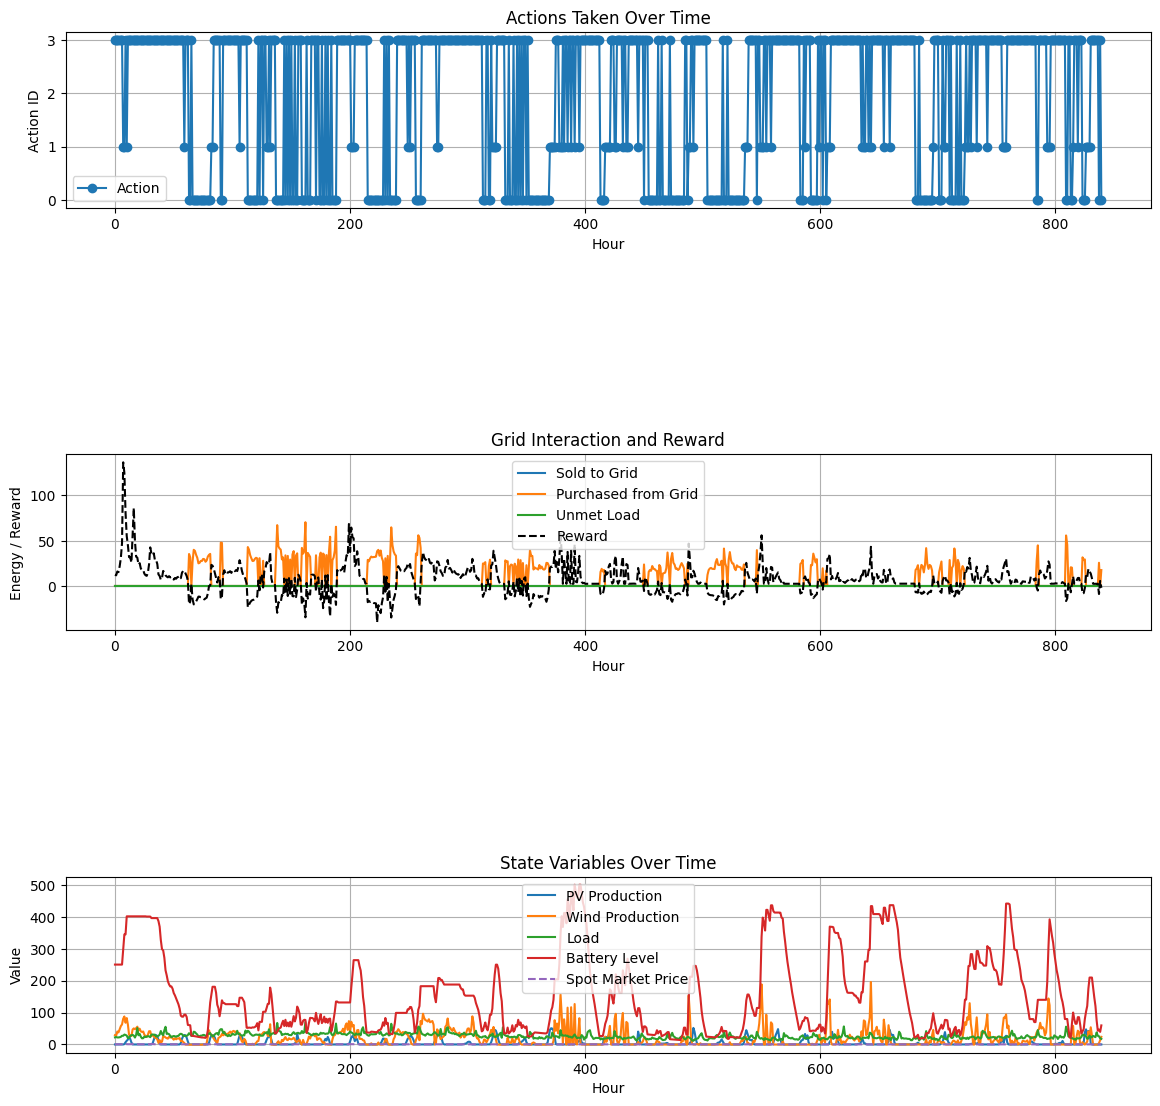

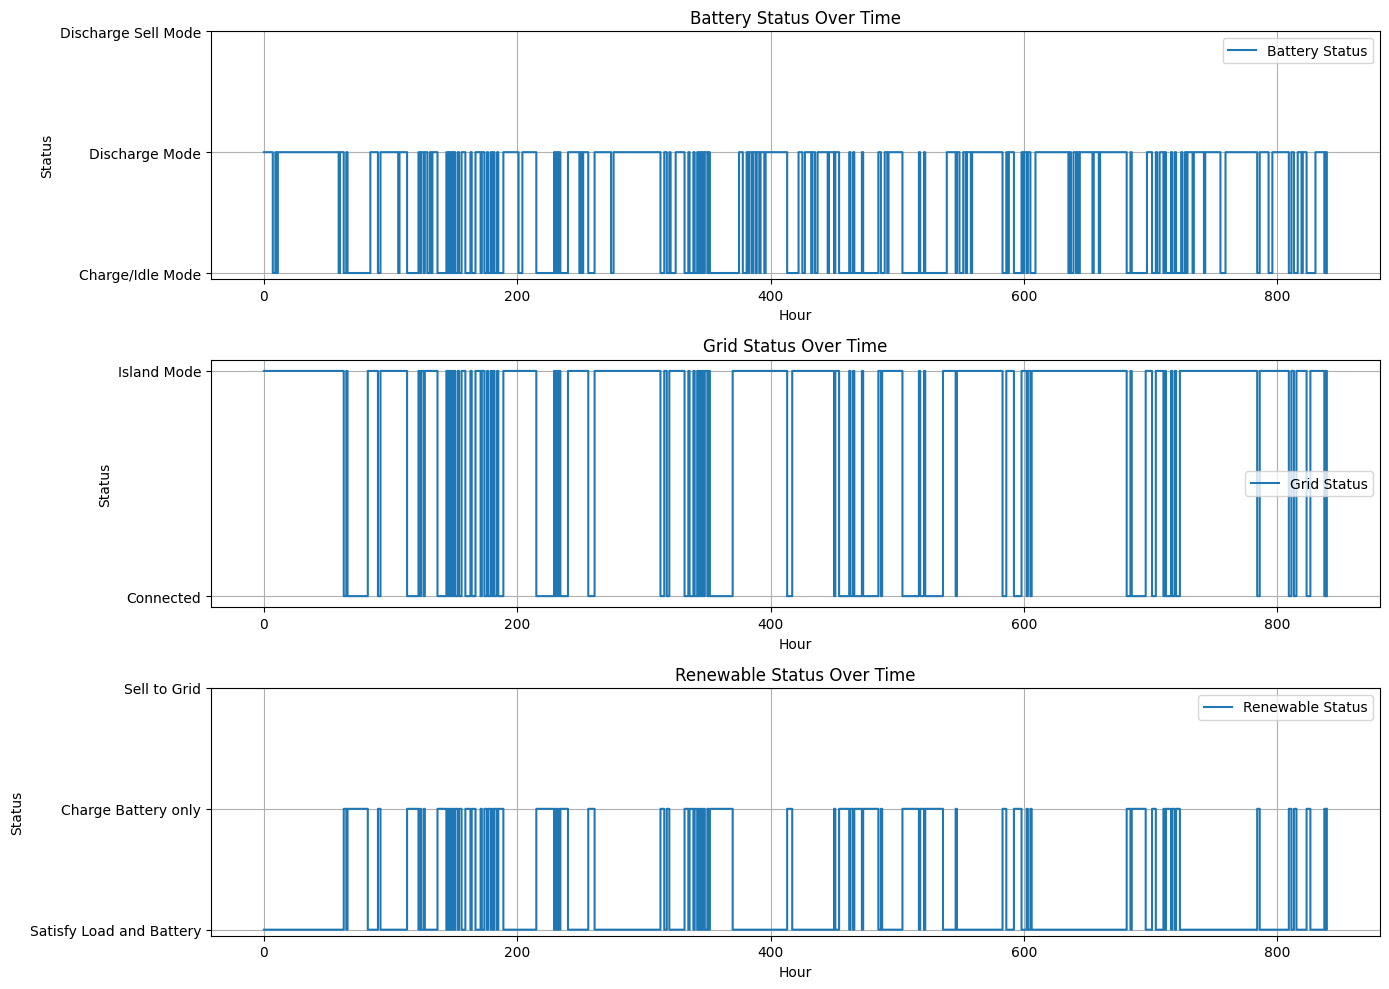

1. % of Load Met with Purchased Energy: 30.61%
2. % of Time Grid in Island Mode: 71.43%
3. Total Purchased Energy Cost: 2868.82 (NOK)


In [ ]:
test_simulate_and_plot(env_2, model, num_days_to_visualize=35)

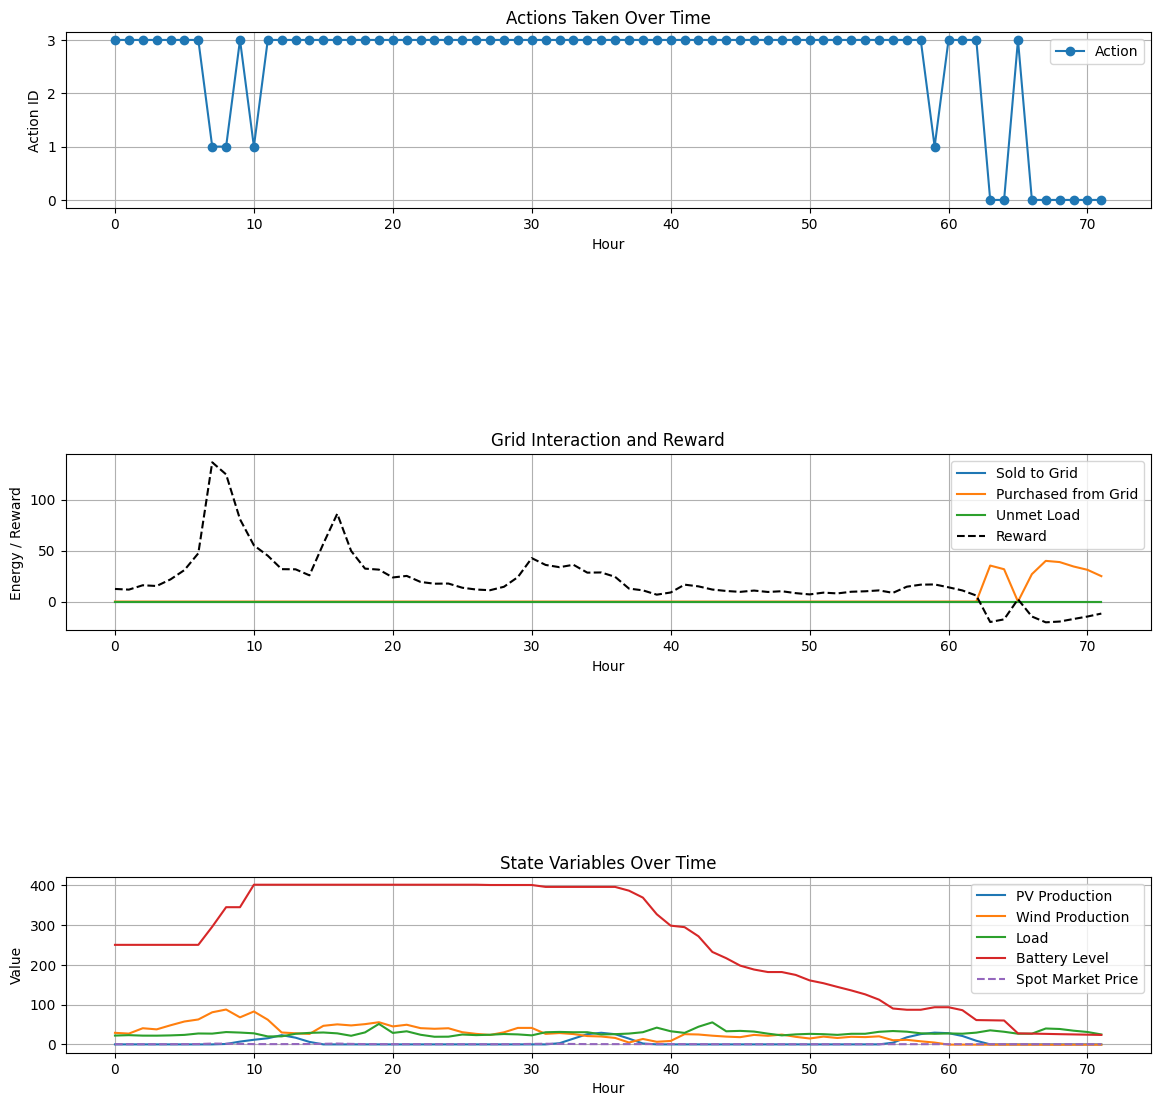

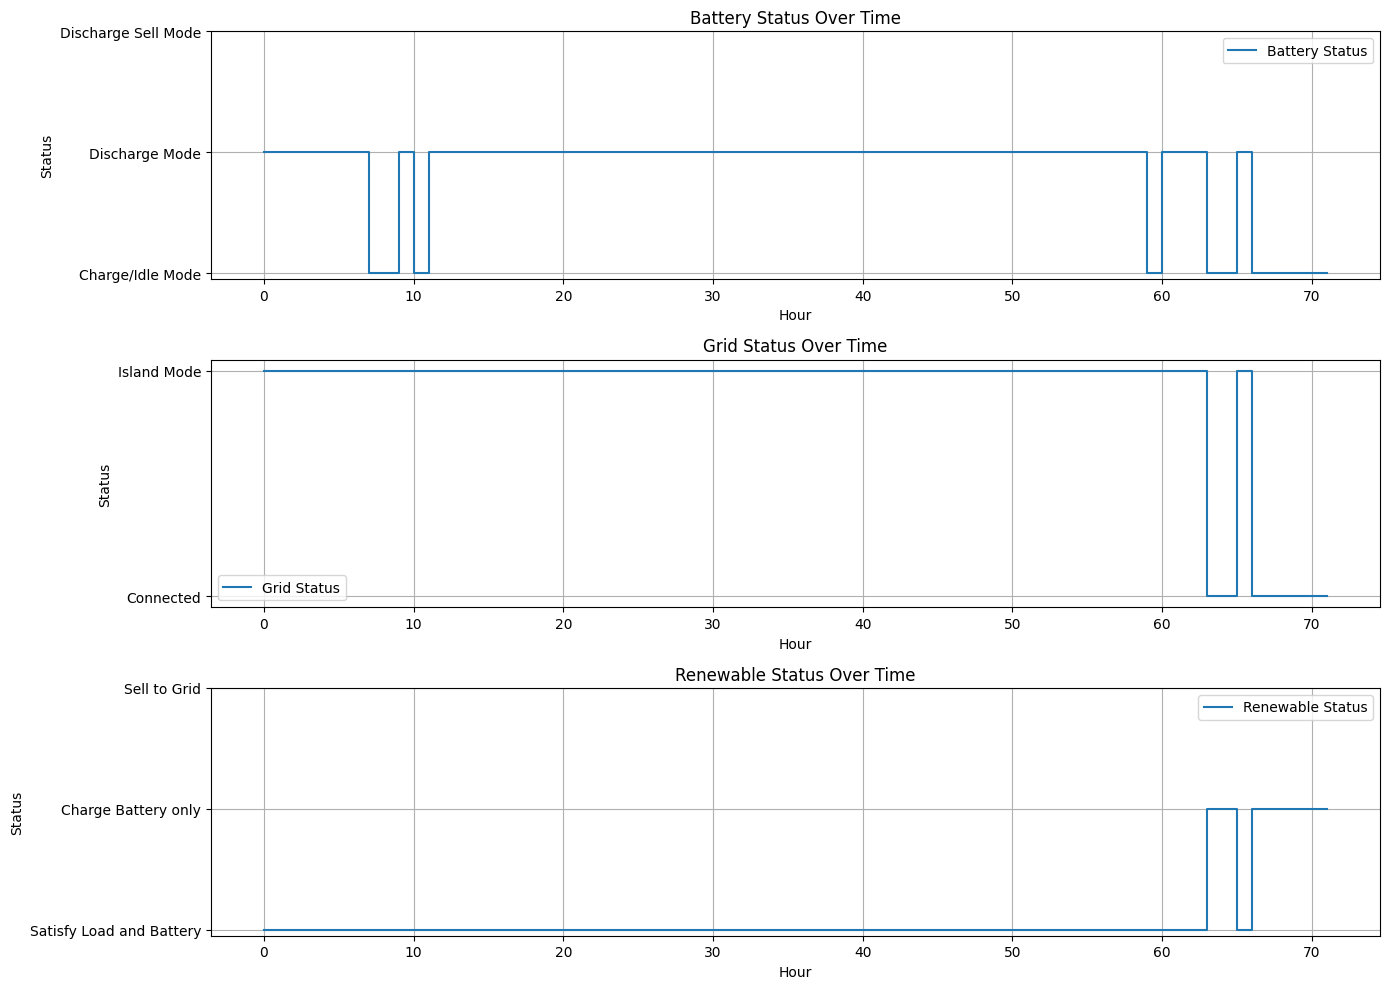

1. % of Load Met with Purchased Energy: 12.72%
2. % of Time Grid in Island Mode: 88.89%
3. Total Purchased Energy Cost: 113.44 (NOK)


In [ ]:
test_simulate_and_plot(env_2, model, num_days_to_visualize=3)

Environment with Forecasting

In [6]:
# Parse time column
df = rye_microgrid_data.copy()
df['time'] = pd.to_datetime(df['time'])

# Extract hour of day
df['hour']   = df['time'].dt.hour

# Build sin/cos features
df['h_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['h_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Day-of-week
df['dow']   = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)

rye_microgrid_data_updated = df

In [7]:
rye_microgrid_data_updated

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d,hour,h_sin,h_cos,dow,month,dow_sin,dow_cos
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.0,0.0,1.0,10.0,64826.0,...,1.0,10.4,247.3,13,-0.258819,-0.965926,2,1,0.974928,-0.222521
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.0,0.0,1.0,0.0,8961.1,...,1.2,10.0,252.1,14,-0.500000,-0.866025,2,1,0.974928,-0.222521
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.0,0.0,1.0,0.0,0.0,...,1.0,11.7,253.8,15,-0.707107,-0.707107,2,1,0.974928,-0.222521
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.0,0.0,1.0,0.0,0.0,...,1.7,14.3,254.2,16,-0.866025,-0.500000,2,1,0.974928,-0.222521
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.0,0.0,1.0,0.0,0.0,...,3.5,13.9,249.7,17,-0.965926,-0.258819,2,1,0.974928,-0.222521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9510,2021-01-31 19:00:00,0.0,21.98,44.422658,0.60243,0.0,0.0,1.0,0.0,0.0,...,-4.3,6.0,238.3,19,-0.965926,0.258819,6,1,-0.781831,0.623490
9511,2021-01-31 20:00:00,0.0,9.60,45.167707,0.53335,0.0,0.0,1.0,0.0,0.0,...,-4.4,6.2,231.8,20,-0.866025,0.500000,6,1,-0.781831,0.623490
9512,2021-01-31 21:00:00,0.0,22.61,32.476198,0.51195,0.0,0.0,1.0,0.0,0.0,...,-4.6,6.0,231.7,21,-0.707107,0.707107,6,1,-0.781831,0.623490
9513,2021-01-31 22:00:00,0.0,21.70,28.561791,0.47122,0.0,0.0,1.0,0.0,0.0,...,-4.9,5.8,231.1,22,-0.500000,0.866025,6,1,-0.781831,0.623490


In [8]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, output_dim, d_model, nhead,
                 num_layers, dropout, window_size):
        super(TimeSeriesTransformer, self).__init__()

        self.encoder = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(window_size, d_model))

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                  dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_dim)

    def forward(self, x):
        # x shape: [batch_size, seq_len, input_dim]
        x = self.encoder(x)  # [batch_size, seq_len, d_model]
        x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
        x = self.transformer_encoder(x)
        x = x[:, -1, :]  # Use the last sequence element for prediction
        x = self.decoder(x)  # [batch_size, output_dim]
        return x

In [9]:
# Loading all trained forecasting models
solar_model = TimeSeriesTransformer(input_dim=4, output_dim=1, d_model=64,
                                    nhead=4, num_layers=2, dropout=0.1, window_size=10)

wind_model = TimeSeriesTransformer(input_dim=1, output_dim=1, d_model=64,
                                   nhead=4, num_layers=2, dropout=0.1, window_size=10)

load_model = TimeSeriesTransformer(input_dim=4, output_dim=1, d_model=64,
                                   nhead=4, num_layers=2, dropout=0.1, window_size=24)

solar_model = torch.load("rye_transformer_solar_model.pth", map_location=torch.device('cpu'), weights_only=False)
wind_model = torch.load("rye_transformer_wind_model.pth", map_location=torch.device('cpu'), weights_only=False)
load_model = torch.load("rye_transformer_load_model.pth", map_location=torch.device('cpu'), weights_only=False)

# set to evaluation mode
solar_model.eval()
wind_model.eval()
load_model.eval()

TimeSeriesTransformer(
  (encoder): Linear(in_features=4, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=64, out_features=1, bias=True)
)

In [10]:
# Creating the scalers
solar_scaler = MinMaxScaler()
solar_scaler.fit(np.array(rye_microgrid_data_updated[['pv_production', 'hour', 'month', 'dow']]))

solar_scaler_eval = MinMaxScaler()
solar_scaler_eval.fit(np.array(df['pv_production']).reshape(-1, 1))

wind_scaler = MinMaxScaler()
wind_scaler.fit(np.array(rye_microgrid_data_updated[['wind_production']]).reshape(-1, 1))

wind_scaler_eval = MinMaxScaler()
wind_scaler_eval.fit(np.array(rye_microgrid_data_updated[['wind_production']]).reshape(-1, 1))

load_scaler = MinMaxScaler()
load_scaler.fit(np.array(rye_microgrid_data_updated[['consumption', 'hour', 'month', 'dow']]))

load_scaler_eval = MinMaxScaler()
load_scaler_eval.fit(np.array(rye_microgrid_data_updated[['consumption']]).reshape(-1, 1))


MinMaxScaler()

In [11]:
solar_preds = []
wind_preds = []
load_preds = []
hours = []

for curr_hour in range(23, len(rye_microgrid_data_updated)):
    try:
        # Solar input: last 10 timesteps
        solar_window = rye_microgrid_data_updated[['pv_production', 'hour', 'month', 'dow']].iloc[curr_hour-9:curr_hour+1].values
        solar_input = torch.tensor(solar_scaler.transform(solar_window), dtype=torch.float32).unsqueeze(0)
        solar_forecast = solar_model(solar_input).item()
        solar_forecast = solar_scaler_eval.inverse_transform([[solar_forecast]])[0][0]

        # Wind input: last 10 timesteps
        wind_window = rye_microgrid_data_updated[['wind_production']].iloc[curr_hour-9:curr_hour+1].values
        wind_input = torch.tensor(wind_scaler.transform(wind_window), dtype=torch.float32).unsqueeze(0)
        wind_forecast = wind_model(wind_input).item()
        wind_forecast = wind_scaler_eval.inverse_transform([[wind_forecast]])[0][0]

        # Load input: last 24 timesteps
        load_window = rye_microgrid_data_updated[['consumption', 'hour', 'month', 'dow']].iloc[curr_hour-23:curr_hour+1].values
        load_input = torch.tensor(load_scaler.transform(load_window), dtype=torch.float32).unsqueeze(0)
        load_forecast = load_model(load_input).item()
        load_forecast = load_scaler_eval.inverse_transform([[load_forecast]])[0][0]

        # Save results
        solar_preds.append(solar_forecast)
        wind_preds.append(wind_forecast)
        load_preds.append(load_forecast)
        hours.append(rye_microgrid_data_updated.loc[curr_hour, 'time'])

    except Exception as e:
        print(f"Skipping hour {curr_hour} due to error: {e}")

rye_microgrid_data_updated['solar_forecast'] = [np.nan]*23 + solar_preds
rye_microgrid_data_updated['wind_forecast']  = [np.nan]*23 + wind_preds
rye_microgrid_data_updated['load_forecast']  = [np.nan]*23 + load_preds

In [16]:
for i in range(len(rye_microgrid_data_updated)):
    # Correct PV production
    if rye_microgrid_data_updated.loc[i, 'pv_production'] < 0:
        deficit = -rye_microgrid_data_updated.loc[i, 'pv_production']
        rye_microgrid_data_updated.loc[i, 'pv_production'] = 0
        rye_microgrid_data_updated.loc[i, 'consumption'] += deficit

    # Correct Wind production
    if rye_microgrid_data_updated.loc[i, 'wind_production'] < 0:
        deficit = -rye_microgrid_data_updated.loc[i, 'wind_production']
        rye_microgrid_data_updated.loc[i, 'wind_production'] = 0
        rye_microgrid_data_updated.loc[i, 'consumption'] += deficit

In [17]:
rye_microgrid_data_updated[:25]

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,hour,h_sin,h_cos,dow,month,dow_sin,dow_cos,solar_forecast,wind_forecast,load_forecast
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.00,0.0,1.0,10.0,64826.0,...,13,-2.588190e-01,-9.659258e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.00,0.0,1.0,0.0,8961.1,...,14,-5.000000e-01,-8.660254e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.00,0.0,1.0,0.0,0.0,...,15,-7.071068e-01,-7.071068e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.00,0.0,1.0,0.0,0.0,...,16,-8.660254e-01,-5.000000e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.00,0.0,1.0,0.0,0.0,...,17,-9.659258e-01,-2.588190e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN
5,2020-01-01 18:00:00,0.0,71.79,36.872878,0.28979,0.00,0.0,1.0,0.0,0.0,...,18,-1.000000e+00,-1.836970e-16,2,1,0.974928,-0.222521,NaN,NaN,NaN
6,2020-01-01 19:00:00,0.0,55.29,56.876120,0.27273,0.25,0.0,12.7,0.0,0.0,...,19,-9.659258e-01,2.588190e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN
7,2020-01-01 20:00:00,0.0,14.80,23.773336,0.26957,0.91,1.0,43.8,0.0,0.0,...,20,-8.660254e-01,5.000000e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN
8,2020-01-01 21:00:00,0.0,5.78,20.893793,0.25527,2.34,1.0,95.0,0.0,0.0,...,21,-7.071068e-01,7.071068e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN
9,2020-01-01 22:00:00,0.0,9.80,19.516569,0.24471,1.38,0.0,66.0,0.0,0.0,...,22,-5.000000e-01,8.660254e-01,2,1,0.974928,-0.222521,NaN,NaN,NaN


In [29]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class RyeMicrogridEnv(gym.Env):
  """
    Custom Microgrid Environment for Rye Microgrid
  """
  def __init__(self, data, num_days):
    super(RyeMicrogridEnv, self).__init__()
    # no of hours to simulate
    self.num_hours = 24 * num_days
    self.curr_hour = 23

    # get the data
    self.data = data

    # setup battery
    self.battery_max = 500
    self.battery_power = 0.5 * self.battery_max # starting at 50%
    self.charge_efficiency = 0.85 # how much power is actually drawn/stored (accounts for losses due to transmission)

    # State consists of PV, Wind, Battery, Load, Price and Forecasts
    self.observation_space = spaces.Box(
        low=np.array([0, 0, 0, 0, 0, 0, 0, 0], dtype=np.float32),
        high=np.array([80, 230, self.battery_max, 100, 2, 80, 230, 100], dtype=np.float32), # max states taken from description of data
        dtype=np.float32
    )

    # Action Space: 7 Actions described above
    self.action_space = spaces.Discrete(7)

    self.state = self._get_observation()

  def _get_observation(self):
    # Returns the state variables
    # Get current data values
    curr_data = self.data.loc[self.curr_hour]

    return np.array([curr_data['pv_production'],
                     curr_data['wind_production'],
                     self.battery_power,
                     curr_data['consumption'],
                     curr_data['spot_market_price'],
                     curr_data['solar_forecast'],
                     curr_data['wind_forecast'],
                     curr_data['load_forecast']], dtype=np.float32)

  def step(self, action):
    # Unpack state
    pv, wind, battery, load, price, solar_f, wind_f, load_f = self.state

    # Set reward and done states
    reward = 0 # total reward
    reward_buy = 0 # reward for buying from grid
    reward_sell = 0 # reward for selling to grid
    reward_renewable_use = 0 # reward for using renewable energy
    reward_unused_load = 0 # reward for unused load
    reward_grid_conn = 0 # reward for connecting/disconnecting to grid
    reward_buy_factor = 1 # buy factor
    reward_sell_factor = 0.6 # sell factor
    reward_renewable_use_factor = 0.8 # factor for using renewable energy
    reward_unused_load_factor = 100 # factor for unused load
    reward_grid_conn_factor = 0.5 # grid connection factor

    done = False # done state

    # Parameters to help visualization
    consumption = load
    unmet = 0
    purchased = 0
    sold = 0

    # Action Handling
    if action == 0: # Use Renewable to charge battery & buy from grid to satisfy load
      self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind))
      purchased = consumption
      unmet = 0 # all energy purchased from grid
      reward_buy -= purchased * price
      reward_grid_conn -= 5
      reward_renewable_use += (pv + wind) * price
    elif action == 1: # Use Renewable for Load while Battery is also charging and Grid is disconnected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_grid_conn += 5
        reward_renewable_use += (pv + wind) * price
        purchased = 0
        self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind - consumption))
      else:
        unmet = consumption - pv - wind
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn += 5
        reward_unused_load -= unmet * price
    elif action == 2: # Use Renewable for Load while Battery is charging and Grid is connected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn -= 5
        purchased = 0
        self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv + wind - consumption))
      else:
        unmet = 0
        reward_renewable_use += (pv + wind) * price
        purchased = consumption - pv - wind
        reward_buy -= (consumption - pv - wind) * price
        reward_grid_conn -= 5
    elif action == 3: # Use both Battery & Renewable for Load while grid is disconnected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn += 5
        purchased = 0
      else:
        if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv - wind):
          unmet = 0
          purchased = 0
          self.battery_power -= (consumption - pv - wind)/self.charge_efficiency
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn += 5
        else:
          unmet = consumption - pv - wind - self.battery_power
          self.battery_power = 0
          purchased = 0
          reward_renewable_use += (pv + wind) * price
          reward_unused_load -= unmet * price
          reward_grid_conn += 5
    elif action == 4: # Use both Battery & Renewable for Load while grid is connected
      if pv + wind >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv + wind) * price
        reward_grid_conn -= 5
        purchased = 0
      else:
        if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv - wind):
          unmet = 0
          purchased = 0
          self.battery_power -= (consumption - pv - wind) / self.charge_efficiency
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn -= 5
        else:
          unmet = 0
          reward_renewable_use += (pv + wind) * price
          reward_grid_conn -= 5
          purchased = consumption - pv - wind
          reward_buy -= purchased * price
    elif action == 5: # Use Renewable for Load and Battery to sell to Grid
      if pv + wind >= consumption:
        unmet = 0
        sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
        self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
        reward_sell += sold * price
        reward_grid_conn -= 5
        reward_renewable_use += (pv + wind) * price
      else:
        unmet = consumption - pv - wind
        sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
        self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
        reward_sell += sold * price
        reward_renewable_use += (pv + wind) * price
        reward_unused_load -= unmet * price
        reward_grid_conn -= 5
    elif action == 6: # Use Renewable to sell and Battery to load
      if self.battery_power >= consumption / self.charge_efficiency:
        unmet = 0
        sold = pv + wind
        self.battery_power -= consumption / self.charge_efficiency
        reward_sell += sold * price
        reward_grid_conn -= 5
      else:
        unmet = consumption - self.charge_efficiency * self.battery_power
        self.battery_power = 0
        sold = pv + wind
        reward_sell += sold * price
        reward_grid_conn -= 5
        reward_unused_load -= unmet * price

    # Update state
    self.curr_hour += 1
    if self.curr_hour >= self.num_hours:
        done = True

    # Calculate reward
    reward += reward_sell * reward_sell_factor + reward_unused_load * reward_unused_load_factor \
              + reward_grid_conn * reward_grid_conn_factor + reward_renewable_use * reward_renewable_use_factor \
              + reward_buy * reward_buy_factor
    # Calculate status for grid, battery, and renewable
    grid_status = "Connected"
    battery_status = "Discharge Mode"
    renewable_status = "Satisfy Load and Battery"
    if reward_grid_conn > 0:
      grid_status = "Island Mode"
    if action == 0 or action == 1 or action == 2:
      battery_status = "Charge/Idle Mode"
    if action == 5:
      battery_status = "Discharge Sell Mode"
    if action == 0:
      renewable_status = "Charge Battery only"
    elif action == 6:
      renewable_status = "Sell to Grid"

    # Update state
    self.state = self._get_observation()
    return self.state, reward, done, False, {
        "sold": sold,
        "unmet": unmet,
        "purchased": purchased,
        "battery": self.battery_power,
        "price": price,
        "load": load,
        "pv": pv,
        "wind": wind,
        "action": action,
        "hour": self.curr_hour,
        "grid_status": grid_status,
        "renewable_status": renewable_status,
        "battery_status": battery_status
    }

  def reset(self, seed=None, options=None):
    # Reset important parameters
    super().reset(seed=seed)
    self.curr_hour = 23
    self.battery_power = 0.5 * self.battery_max
    self.state = self._get_observation()
    return self.state, {}


In [30]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Create and wrap environment
num_days = 365
env = RyeMicrogridEnv(rye_microgrid_data_updated, num_days)
vec_env = make_vec_env(lambda: env, n_envs=1)

# Train the PPO agent
model = PPO("MlpPolicy", vec_env, verbose=1)
model.learn(total_timesteps=1000000)


# Save the model
model.save("ppo_microgrid_final")

Using cuda device


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
|    value_loss           | 1.12e+03     |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 8.74e+03     |
|    ep_rew_mean          | 1.4e+03      |
| time/                   |              |
|    fps                  | 396          |
|    iterations           | 252          |
|    time_elapsed         | 1300         |
|    total_timesteps      | 516096       |
| train/                  |              |
|    approx_kl            | 0.0016727307 |
|    clip_fraction        | 0.00967      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.381       |
|    explained_variance   | 0.544        |
|    learning_rate        | 0.0003       |
|    loss                 | 969          |
|    n_updates            | 2510         |
|    policy_gradient_loss | -0.00172     |
|    value_loss           | 3.36e+03     |
---

In [26]:
# Helper Function to simulate and plot on test set
def simulate_and_plot(env, model, num_days_to_visualize=2):
    state, _ = env.reset()
    done = False

    log = {
        "hour": [],
        "action": [],
        "sold": [],
        "unmet": [],
        "purchased": [],
        "battery": [],
        "price": [],
        "load": [],
        "pv": [],
        "wind": [],
        "reward": [],
        "battery_status": [],
        "grid_status": [],
        "renewable_status": []
    }

    steps_to_visualize = 24 * num_days_to_visualize

    for _ in range(steps_to_visualize):
        action, _ = model.predict(state, deterministic=True)
        next_state, reward, done, _, info = env.step(action)

        for key in log:
            if key == "reward":
                log["reward"].append(reward)
            else:
                log[key].append(info[key])

        state = next_state
        if done:
            break

    hours = list(range(len(log["action"])))
    plt.figure(figsize=(14, 16))

    plt.subplot(4, 1, 1)
    plt.plot(hours, log["action"], label="Action", marker='o')
    plt.title("Actions Taken Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Action ID")
    plt.grid(True)
    plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(hours, log["sold"], label="Sold to Grid")
    plt.plot(hours, log["purchased"], label="Purchased from Grid")
    plt.plot(hours, log["unmet"], label="Unmet Load")
    plt.plot(hours, log["reward"], label="Reward", linestyle='--', color='black')
    plt.title("Grid Interaction and Reward")
    plt.xlabel("Hour")
    plt.ylabel("Energy / Reward")
    plt.grid(True)
    plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(hours, log["pv"], label="PV Production")
    plt.plot(hours, log["wind"], label="Wind Production")
    plt.plot(hours, log["load"], label="Load")
    plt.plot(hours, log["battery"], label="Battery Level")
    plt.plot(hours, log["price"], label="Spot Market Price", linestyle='--')
    plt.title("State Variables Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    battery_status_map = {
        "Charge/Idle Mode": 0,
        "Discharge Mode": 1,
        "Discharge Sell Mode": 2
    }
    grid_status_map = {
        "Connected": 0,
        "Island Mode": 1
    }
    renewable_status_map = {
        "Satisfy Load and Battery": 0,
        "Charge Battery only": 1,
        "Sell to Grid": 2
    }

    battery_status_vals = [battery_status_map.get(s, -1) for s in log["battery_status"]]
    grid_status_vals = [grid_status_map.get(s, -1) for s in log["grid_status"]]
    renewable_status_vals = [renewable_status_map.get(s, -1) for s in log["renewable_status"]]

    plt.figure(figsize=(14, 10))
    plt.subplot(3, 1, 1)
    plt.plot(hours, battery_status_vals, label="Battery Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Charge/Idle Mode", "Discharge Mode", "Discharge Sell Mode"])
    plt.title("Battery Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(hours, grid_status_vals, label="Grid Status", drawstyle='steps-post')
    plt.yticks([0, 1], ["Connected", "Island Mode"])
    plt.title("Grid Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(hours, renewable_status_vals, label="Renewable Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Satisfy Load and Battery", "Charge Battery only", "Sell to Grid"])
    plt.title("Renewable Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


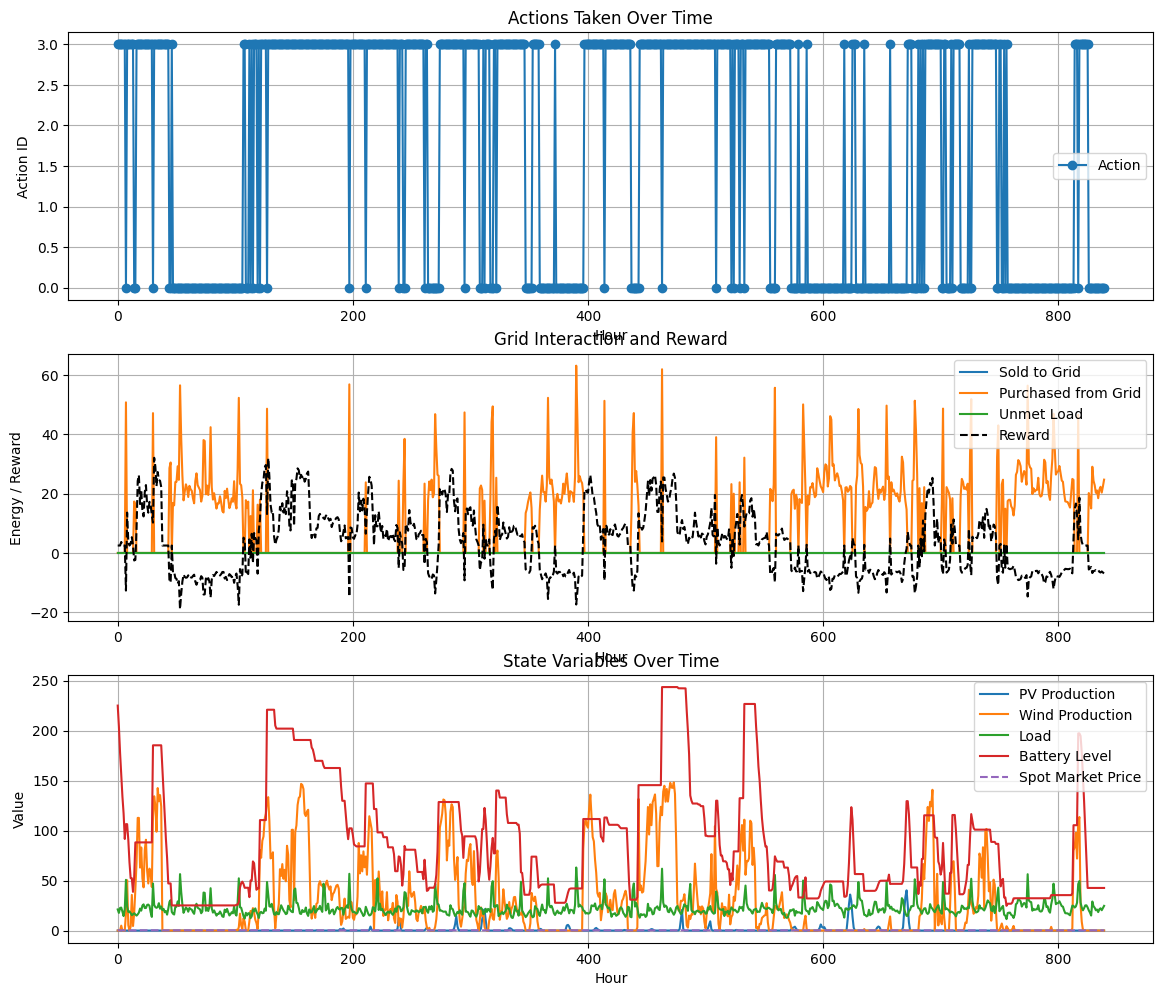

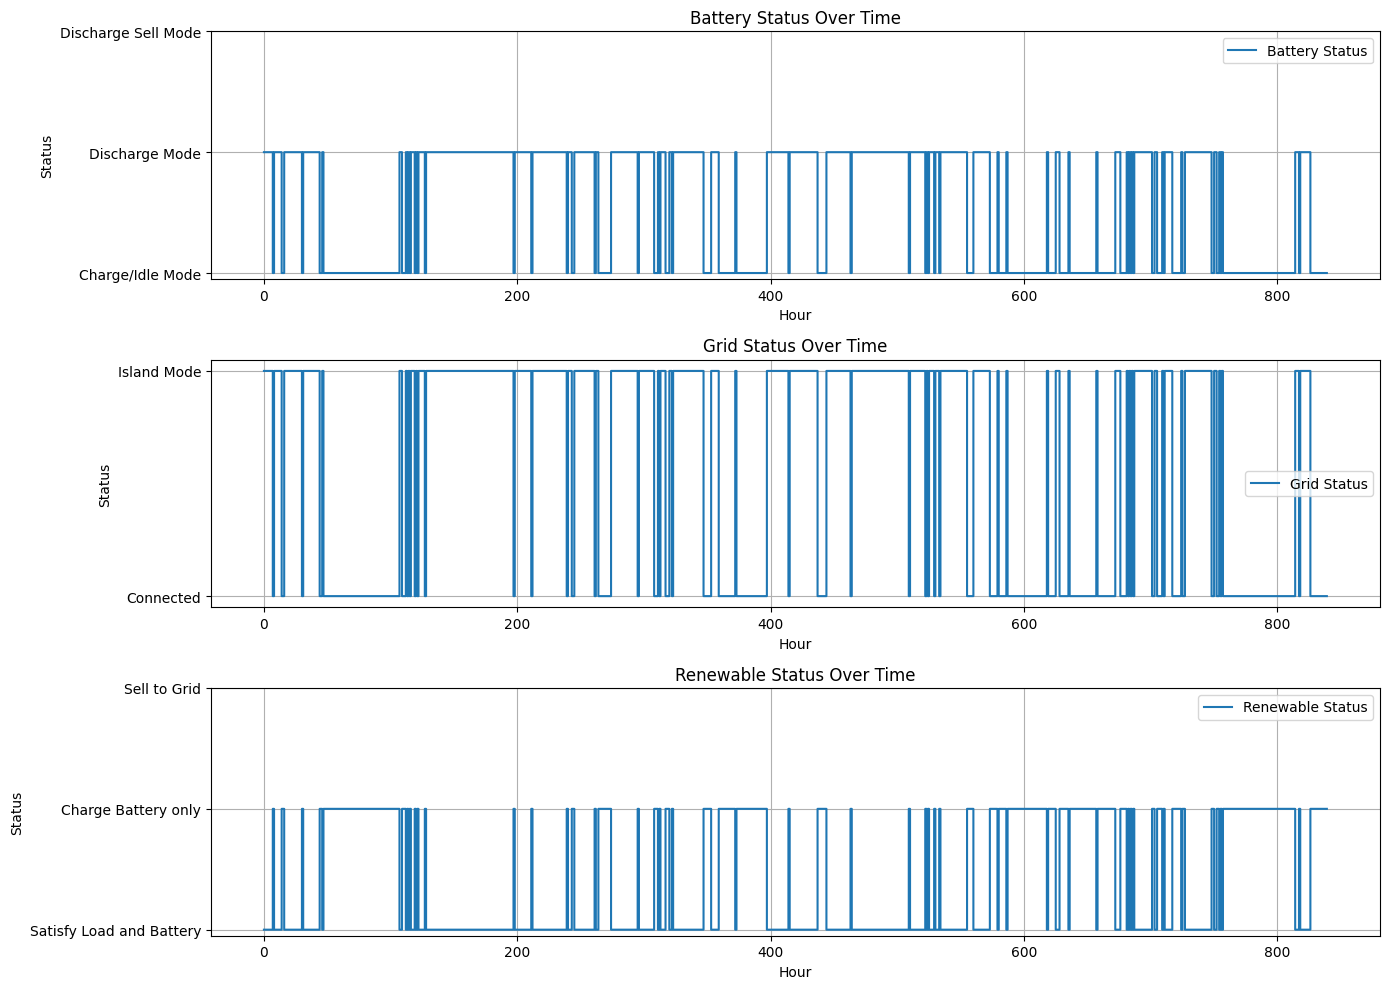

In [31]:
simulate_and_plot(env, model, num_days_to_visualize=35)

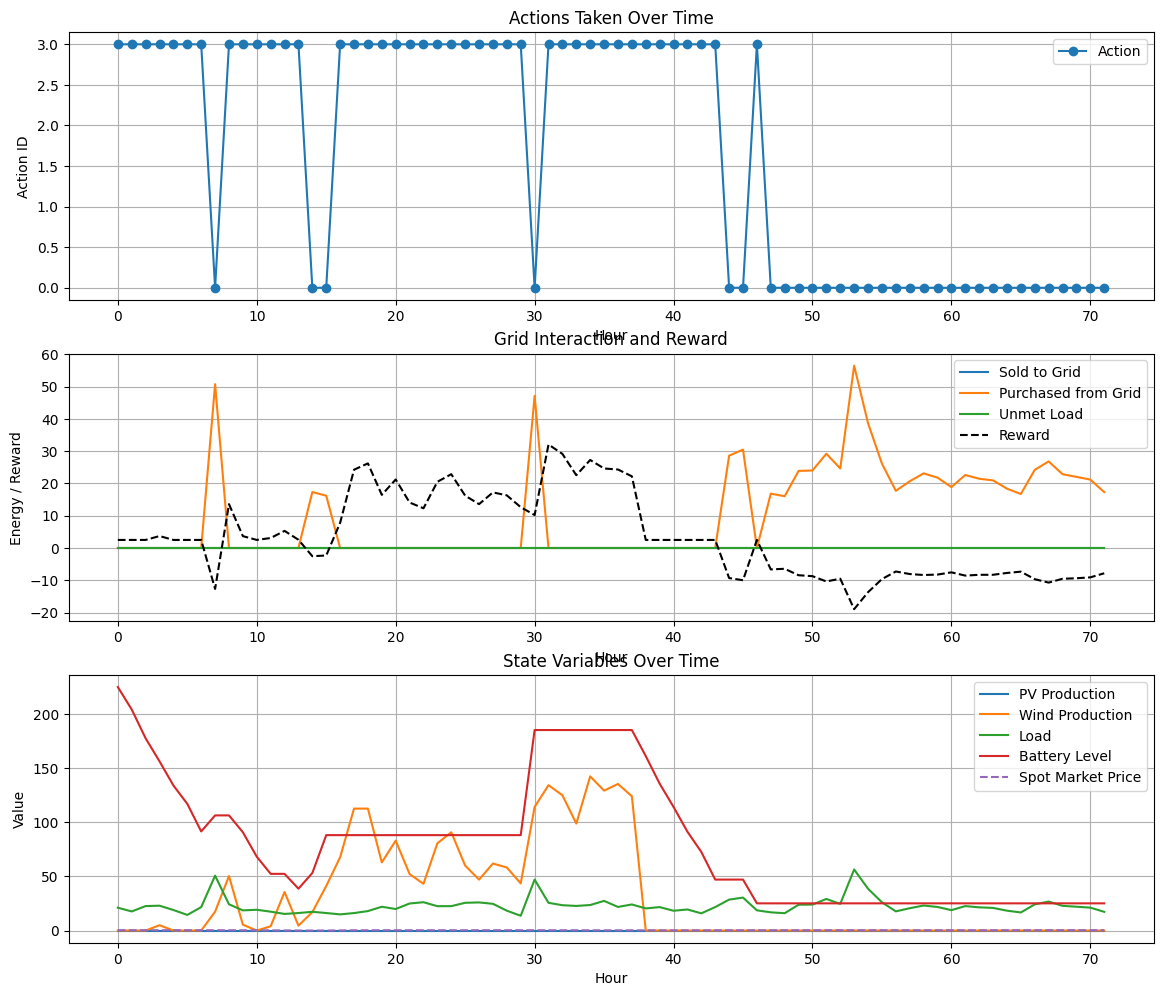

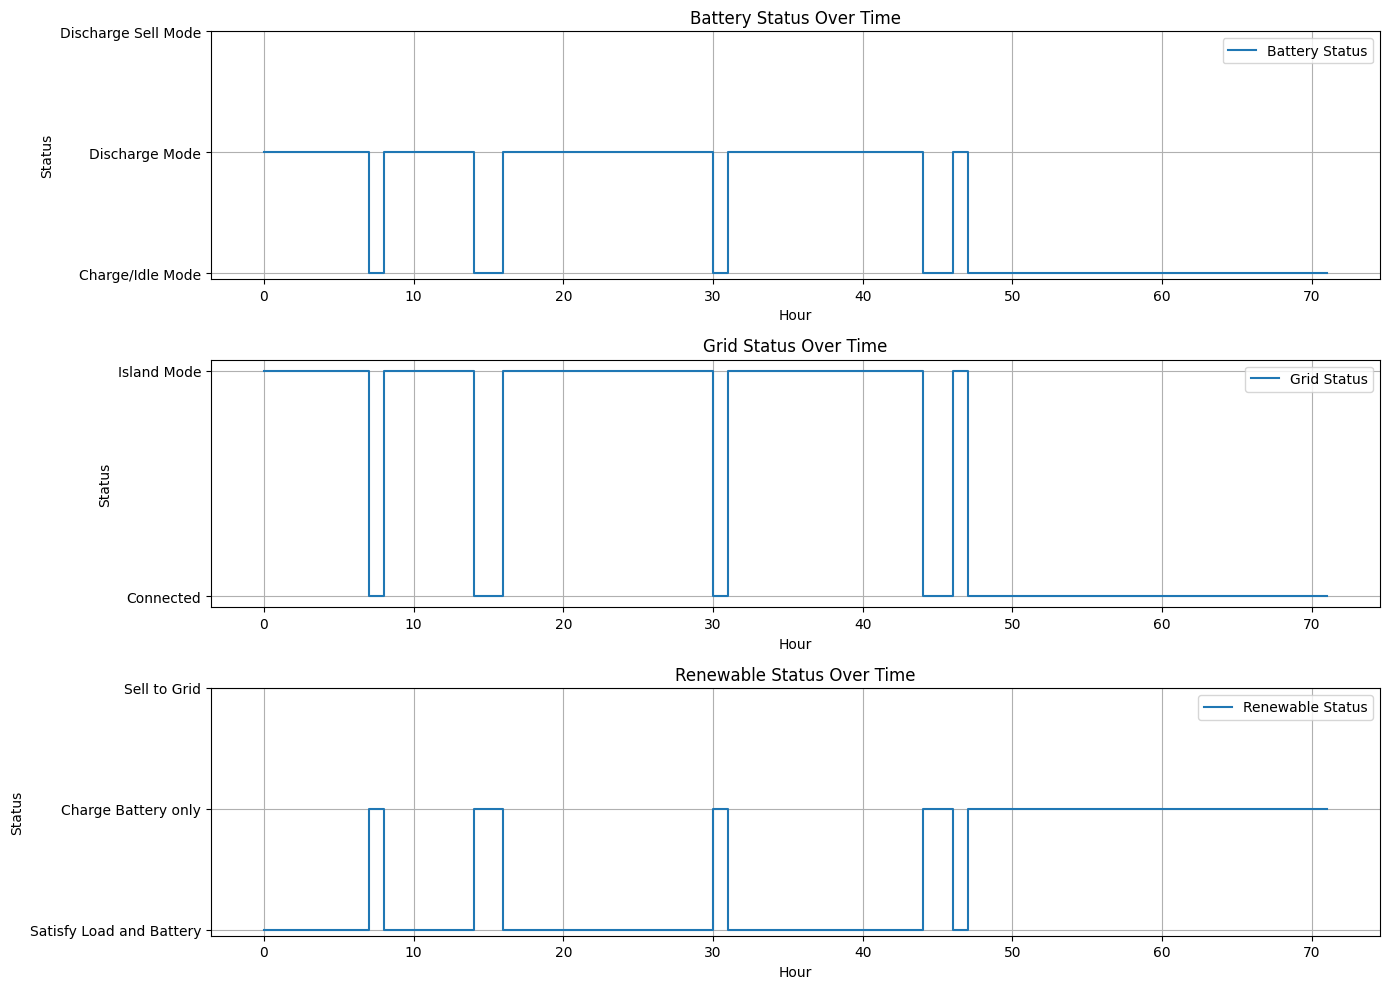

In [32]:
simulate_and_plot(env, model, num_days_to_visualize=3)

Evaluating New Environment on Test Set

In [51]:
rye_test = pd.read_csv('test.csv')
rye_test

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2021-02-01 00:00:00,0.0,29.02,37.731253,0.42572,0.0,0.0,1.0,0.0,0.0,...,-4.3,91.9,-5.4,4.0,213.8,-3.7,88.8,-5.3,5.1,223.2
1,2021-02-01 01:00:00,0.0,27.09,39.288933,0.42531,0.0,0.0,1.0,0.0,0.0,...,-4.6,91.5,-5.8,4.0,205.6,-4.0,87.8,-5.7,5.1,214.8
2,2021-02-01 02:00:00,0.0,40.56,37.472487,0.41575,0.0,0.0,1.0,0.0,0.0,...,-4.9,91.2,-6.1,4.3,203.8,-4.1,86.9,-5.9,5.6,212.1
3,2021-02-01 03:00:00,0.0,37.72,37.343327,0.42344,0.0,0.0,1.0,0.0,0.0,...,-5.2,89.9,-6.6,4.3,201.7,-4.3,85.0,-6.4,5.6,210.4
4,2021-02-01 04:00:00,0.0,47.98,38.386463,0.50187,0.0,0.0,1.0,0.0,0.0,...,-5.6,88.3,-7.2,4.0,194.6,-4.5,82.4,-7.0,5.0,201.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,2021-03-07 20:00:00,0.0,-0.36,45.174683,0.28008,0.0,0.0,1.0,0.0,0.0,...,-1.2,86.0,-3.2,4.5,268.9,-1.5,86.1,-3.5,5.4,274.8
837,2021-03-07 21:00:00,0.0,4.20,42.956577,0.28772,0.0,0.0,1.0,0.0,0.0,...,-1.4,86.5,-3.4,4.1,260.6,-1.7,86.1,-3.7,5.0,266.6
838,2021-03-07 22:00:00,0.0,13.24,33.505287,0.28761,0.0,0.0,1.0,0.0,0.0,...,-1.9,86.5,-3.8,3.8,252.3,-2.1,85.5,-4.2,4.7,258.2
839,2021-03-07 23:00:00,0.0,23.88,30.679047,0.27743,0.0,0.0,1.0,0.0,0.0,...,-2.5,88.4,-4.1,3.7,236.9,-2.7,87.1,-4.5,4.7,244.9


In [52]:
rye_test.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,8.410000e+02,841.000000,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,4.510592,20.086468,44.285889,0.404042,0.030666,0.019025,2.037812,48.115339,1.731789e+05,18.186326,...,-2.948989,77.081332,-6.583115,4.394530,189.633294,-2.668847,74.462663,-6.831986,5.215696,193.220690
std,9.632409,27.797933,12.727659,0.175913,0.262185,0.181579,7.707197,83.383694,2.981970e+05,30.160481,...,7.035947,13.169365,7.295046,2.422163,64.746351,6.789937,14.480448,7.243487,2.917581,64.183272
min,0.000000,-0.850000,21.420865,0.165030,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-17.100000,40.900000,-21.000000,0.600000,17.600000,-17.000000,32.200000,-21.700000,0.100000,17.800000
25%,0.000000,-0.260000,34.778583,0.278580,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-9.300000,68.500000,-14.100000,2.400000,137.900000,-8.400000,66.800000,-14.100000,2.700000,148.500000
50%,0.000000,9.440000,42.102347,0.396150,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-1.400000,79.300000,-6.200000,4.000000,178.400000,-1.700000,76.300000,-6.400000,4.800000,180.000000
75%,2.946333,30.890000,52.058330,0.456690,0.000000,0.000000,1.000000,75.000000,2.603562e+05,32.600000,...,3.300000,87.400000,0.800000,5.700000,244.600000,3.400000,85.200000,0.500000,6.900000,248.300000
max,51.827334,195.570000,111.059900,2.077080,4.660000,3.000000,95.000000,339.700000,1.232206e+06,128.400000,...,10.300000,100.000000,5.200000,13.900000,344.300000,10.200000,100.000000,4.800000,15.700000,345.800000


In [53]:
rye_microgrid_data.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9.515000e+03,9515.000000,...,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.00000,9515.000000
mean,7.654312,21.254382,20.262091,0.127386,0.066322,0.039096,3.312181,144.807325,5.213013e+05,38.549511,...,5.729207,76.279443,1.591088,4.283847,195.021703,5.633558,74.844782,1.220410,5.11671,198.633568
std,15.673519,38.225468,8.311275,0.125292,0.353434,0.239879,10.585675,232.985222,8.366789e+05,59.636149,...,6.927206,13.792720,6.265550,2.241726,81.361187,6.836455,14.001831,6.255477,2.67242,81.089361
min,0.000000,-582.200000,0.048396,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-14.800000,23.400000,-16.300000,0.100000,0.100000,-14.600000,22.300000,-16.600000,0.10000,0.300000
25%,0.000000,-0.260000,14.757704,0.044375,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,1.200000,67.400000,-2.700000,2.500000,134.100000,1.000000,65.900000,-3.100000,3.00000,142.950000
50%,0.000000,2.370000,18.817098,0.090390,0.000000,0.000000,1.000000,0.000000,3.637200e+03,0.000000,...,4.600000,78.400000,1.200000,4.000000,190.400000,4.500000,76.800000,0.900000,4.90000,192.300000
75%,6.411375,26.040000,23.716080,0.165970,0.000000,0.000000,1.000000,220.800000,7.768631e+05,63.900000,...,10.200000,87.100000,6.400000,5.600000,265.500000,10.100000,85.700000,6.000000,6.70000,267.700000
max,79.855834,225.500000,70.366622,1.140590,6.220000,3.000000,95.000000,834.800000,3.004661e+06,320.200000,...,29.700000,100.000000,17.000000,15.300000,359.900000,29.600000,100.000000,16.500000,17.40000,359.700000


In [54]:
# Extracting specific month and days from the train
# Ensure 'time' is in datetime format
df1 = rye_test.copy()
df2 = rye_microgrid_data.copy()
df1['time'] = pd.to_datetime(df1['time'])
df2['time'] = pd.to_datetime(df2['time'])

# Create common key based on month, day, hour, and minute
df1['match_key'] = df1['time'].dt.strftime('%m-%d %H:%M')
df2['match_key'] = df2['time'].dt.strftime('%m-%d %H:%M')

# Filter df2 to rows that match df1's timestamps (ignoring year)
df2_matched = df2[df2['match_key'].isin(df1['match_key'])]

# Drop the helper column
df1.drop(columns='match_key', inplace=True)
df2_matched.drop(columns='match_key', inplace=True)
rye_train_rel = df2_matched.reset_index(drop=True)
rye_train_rel

<ipython-input-54-0c21a05f7cf1>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_matched.drop(columns='match_key', inplace=True)


,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2020-02-01 00:00:00,0.0,24.45,18.009981,0.15487,0.00,0.0,1.0,0.0,0.0,...,1.6,70.4,-3.2,4.2,153.3,1.4,68.0,-3.8,5.7,161.3
1,2020-02-01 01:00:00,0.0,57.05,18.958709,0.15477,0.00,0.0,1.0,0.0,0.0,...,2.0,71.1,-2.7,3.9,130.4,1.8,68.1,-3.4,4.8,145.3
2,2020-02-01 02:00:00,0.0,68.15,18.440980,0.15640,0.00,0.0,1.0,0.0,0.0,...,2.0,68.0,-3.3,4.2,151.3,1.8,66.1,-3.9,5.5,161.6
3,2020-02-01 03:00:00,0.0,69.37,17.492381,0.15853,0.00,0.0,1.0,0.0,0.0,...,1.9,68.7,-3.2,3.7,149.0,1.7,67.1,-3.8,4.9,162.3
4,2020-02-01 04:00:00,0.0,42.16,16.040638,0.16108,0.00,0.0,1.0,0.0,0.0,...,1.6,74.7,-2.4,4.1,136.7,1.3,73.4,-2.9,5.1,151.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,2020-03-07 20:00:00,0.0,145.28,21.321811,0.13620,0.00,0.0,1.0,0.0,0.0,...,-0.8,64.1,-6.7,5.1,150.8,-1.0,62.1,-7.3,6.8,159.9
837,2020-03-07 21:00:00,0.0,173.14,21.645391,0.13065,0.00,0.0,1.0,0.0,0.0,...,-0.4,63.0,-6.6,5.5,149.0,-0.6,61.1,-7.2,7.2,159.3
838,2020-03-07 22:00:00,0.0,92.00,21.720153,0.12562,0.17,3.0,8.5,0.0,0.0,...,-0.1,62.9,-6.3,5.9,154.7,-0.2,61.4,-6.8,7.7,162.9
839,2020-03-07 23:00:00,0.0,127.03,22.942129,0.10856,1.67,3.0,71.4,0.0,0.0,...,0.1,64.5,-5.8,6.2,155.1,-0.1,63.2,-6.3,8.0,164.0


In [55]:
rye_train_rel.describe()

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,841,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,8.410000e+02,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,2020-02-18 16:49:22.187871744,4.668120,32.991165,23.505811,0.140935,0.050024,0.046373,2.948157,47.141617,1.697069e+05,...,0.087396,76.932461,-3.645541,4.875268,180.494174,0.096790,74.899049,-4.012485,5.975030,186.139477
min,2020-02-01 00:00:00,0.000000,-0.610000,11.426423,0.047250,0.000000,0.000000,1.000000,0.000000,0.000000e+00,...,-8.900000,41.900000,-16.300000,0.300000,7.300000,-8.600000,40.800000,-16.600000,0.200000,13.000000
25%,2020-02-09 18:00:00,0.000000,-0.280000,18.798467,0.112400,0.000000,0.000000,1.000000,0.000000,0.000000e+00,...,-1.500000,67.300000,-5.700000,3.200000,136.200000,-1.500000,64.800000,-6.200000,4.000000,146.200000
50%,2020-02-18 12:00:00,0.000000,11.800000,21.999036,0.141380,0.000000,0.000000,1.000000,0.000000,0.000000e+00,...,0.500000,78.800000,-3.100000,4.400000,180.900000,0.500000,76.200000,-3.400000,5.700000,184.100000
75%,2020-02-27 06:00:00,1.181417,42.780000,25.298744,0.167130,0.000000,0.000000,1.000000,69.700000,2.555562e+05,...,2.200000,86.700000,-0.900000,6.500000,229.100000,2.000000,84.700000,-1.400000,8.000000,238.200000
max,2020-03-08 00:00:00,64.869416,225.500000,70.366622,0.252060,3.080000,3.000000,95.000000,341.300000,1.239120e+06,...,6.900000,99.200000,3.300000,12.300000,336.400000,6.600000,99.800000,3.000000,14.200000,349.200000
std,NaN,12.053125,48.602958,8.057081,0.037952,0.262449,0.318463,9.810515,82.463685,2.949002e+05,...,3.069610,12.585211,3.637943,2.288144,63.399917,2.954218,12.946966,3.688628,2.713857,63.403925


In [56]:
# Columns to scale
cols_to_scale = ['consumption']

# Scale Test's Min/Max to that of Train
scaler = MinMaxScaler()
rye_test[cols_to_scale] = scaler.fit_transform(rye_test[cols_to_scale])
scaler = MinMaxScaler()
scaler.fit(rye_train_rel[cols_to_scale])
rye_test[cols_to_scale] = scaler.inverse_transform(rye_test[cols_to_scale])
rye_test.describe()

,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,diffuse_rad:W,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,8.410000e+02,841.000000,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,4.510592,20.086468,26.460823,0.404042,0.030666,0.019025,2.037812,48.115339,1.731789e+05,18.186326,...,-2.948989,77.081332,-6.583115,4.394530,189.633294,-2.668847,74.462663,-6.831986,5.215696,193.220690
std,9.632409,27.797933,8.368795,0.175913,0.262185,0.181579,7.707197,83.383694,2.981970e+05,30.160481,...,7.035947,13.169365,7.295046,2.422163,64.746351,6.789937,14.480448,7.243487,2.917581,64.183272
min,0.000000,-0.850000,11.426423,0.165030,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-17.100000,40.900000,-21.000000,0.600000,17.600000,-17.000000,32.200000,-21.700000,0.100000,17.800000
25%,0.000000,-0.260000,20.209501,0.278580,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-9.300000,68.500000,-14.100000,2.400000,137.900000,-8.400000,66.800000,-14.100000,2.700000,148.500000
50%,0.000000,9.440000,25.025082,0.396150,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,...,-1.400000,79.300000,-6.200000,4.000000,178.400000,-1.700000,76.300000,-6.400000,4.800000,180.000000
75%,2.946333,30.890000,31.571422,0.456690,0.000000,0.000000,1.000000,75.000000,2.603562e+05,32.600000,...,3.300000,87.400000,0.800000,5.700000,244.600000,3.400000,85.200000,0.500000,6.900000,248.300000
max,51.827334,195.570000,70.366622,2.077080,4.660000,3.000000,95.000000,339.700000,1.232206e+06,128.400000,...,10.300000,100.000000,5.200000,13.900000,344.300000,10.200000,100.000000,4.800000,15.700000,345.800000


In [57]:
# Parse time column
df = rye_test.copy()
df['time'] = pd.to_datetime(df['time'])

# Extract hour of day
df['hour']   = df['time'].dt.hour

# Build sin/cos features
df['h_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['h_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Day-of-week
df['dow']   = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)

rye_test_updated = df

In [58]:
# Creating the scalers
solar_scaler = MinMaxScaler()
solar_scaler.fit(np.array(rye_test_updated[['pv_production', 'hour', 'month', 'dow']]))

solar_scaler_eval = MinMaxScaler()
solar_scaler_eval.fit(np.array(rye_test_updated['pv_production']).reshape(-1, 1))

wind_scaler = MinMaxScaler()
wind_scaler.fit(np.array(rye_test_updated[['wind_production']]).reshape(-1, 1))

wind_scaler_eval = MinMaxScaler()
wind_scaler_eval.fit(np.array(rye_test_updated[['wind_production']]).reshape(-1, 1))

load_scaler = MinMaxScaler()
load_scaler.fit(np.array(rye_test_updated[['consumption', 'hour', 'month', 'dow']]))

load_scaler_eval = MinMaxScaler()
load_scaler_eval.fit(np.array(rye_test_updated[['consumption']]).reshape(-1, 1))


MinMaxScaler()

In [59]:
solar_preds = []
wind_preds = []
load_preds = []
hours = []

for curr_hour in range(23, len(rye_test_updated)):
    try:
        # Solar input: last 10 timesteps
        solar_window = rye_test_updated[['pv_production', 'hour', 'month', 'dow']].iloc[curr_hour-9:curr_hour+1].values
        solar_input = torch.tensor(solar_scaler.transform(solar_window), dtype=torch.float32).unsqueeze(0)
        solar_forecast = solar_model(solar_input).item()
        solar_forecast = solar_scaler_eval.inverse_transform([[solar_forecast]])[0][0]

        # Wind input: last 10 timesteps
        wind_window = rye_test_updated[['wind_production']].iloc[curr_hour-9:curr_hour+1].values
        wind_input = torch.tensor(wind_scaler.transform(wind_window), dtype=torch.float32).unsqueeze(0)
        wind_forecast = wind_model(wind_input).item()
        wind_forecast = wind_scaler_eval.inverse_transform([[wind_forecast]])[0][0]

        # Load input: last 24 timesteps
        load_window = rye_test_updated[['consumption', 'hour', 'month', 'dow']].iloc[curr_hour-23:curr_hour+1].values
        load_input = torch.tensor(load_scaler.transform(load_window), dtype=torch.float32).unsqueeze(0)
        load_forecast = load_model(load_input).item()
        load_forecast = load_scaler_eval.inverse_transform([[load_forecast]])[0][0]

        # Save results
        solar_preds.append(solar_forecast)
        wind_preds.append(wind_forecast)
        load_preds.append(load_forecast)
        hours.append(rye_test_updated.loc[curr_hour, 'time'])

    except Exception as e:
        print(f"Skipping hour {curr_hour} due to error: {e}")

rye_test_updated['solar_forecast'] = [np.nan]*23 + solar_preds
rye_test_updated['wind_forecast']  = [np.nan]*23 + wind_preds
rye_test_updated['load_forecast']  = [np.nan]*23 + load_preds

In [60]:
for i in range(len(rye_test_updated)):
    # Correct PV production
    if rye_test_updated.loc[i, 'pv_production'] < 0:
        deficit = -rye_test_updated.loc[i, 'pv_production']
        rye_test_updated.loc[i, 'pv_production'] = 0
        rye_test_updated.loc[i, 'consumption'] += deficit

    # Correct Wind production
    if rye_test_updated.loc[i, 'wind_production'] < 0:
        deficit = -rye_test_updated.loc[i, 'wind_production']
        rye_test_updated.loc[i, 'wind_production'] = 0
        rye_test_updated.loc[i, 'consumption'] += deficit

In [62]:
rye_test_updated

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,hour,h_sin,h_cos,dow,month,dow_sin,dow_cos,solar_forecast,wind_forecast,load_forecast
0,2021-02-01 00:00:00,0.0,29.02,22.150965,0.42572,0.0,0.0,1.0,0.0,0.0,...,0,0.000000,1.000000,0,2,0.000000,1.00000,NaN,NaN,NaN
1,2021-02-01 01:00:00,0.0,27.09,23.175183,0.42531,0.0,0.0,1.0,0.0,0.0,...,1,0.258819,0.965926,0,2,0.000000,1.00000,NaN,NaN,NaN
2,2021-02-01 02:00:00,0.0,40.56,21.980818,0.41575,0.0,0.0,1.0,0.0,0.0,...,2,0.500000,0.866025,0,2,0.000000,1.00000,NaN,NaN,NaN
3,2021-02-01 03:00:00,0.0,37.72,21.895892,0.42344,0.0,0.0,1.0,0.0,0.0,...,3,0.707107,0.707107,0,2,0.000000,1.00000,NaN,NaN,NaN
4,2021-02-01 04:00:00,0.0,47.98,22.581784,0.50187,0.0,0.0,1.0,0.0,0.0,...,4,0.866025,0.500000,0,2,0.000000,1.00000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,2021-03-07 20:00:00,0.0,0.00,27.405230,0.28008,0.0,0.0,1.0,0.0,0.0,...,20,-0.866025,0.500000,6,3,-0.781831,0.62349,0.125846,142.384195,26.220852
837,2021-03-07 21:00:00,0.0,4.20,25.586762,0.28772,0.0,0.0,1.0,0.0,0.0,...,21,-0.707107,0.707107,6,3,-0.781831,0.62349,0.114553,142.441234,22.784197
838,2021-03-07 22:00:00,0.0,13.24,19.372272,0.28761,0.0,0.0,1.0,0.0,0.0,...,22,-0.500000,0.866025,6,3,-0.781831,0.62349,0.109790,142.473547,21.037824
839,2021-03-07 23:00:00,0.0,23.88,17.513939,0.27743,0.0,0.0,1.0,0.0,0.0,...,23,-0.258819,0.965926,6,3,-0.781831,0.62349,0.131192,142.479389,21.855098


In [65]:
# Create and wrap environment
num_days = 34
env_2 = RyeMicrogridEnv(rye_test_updated, num_days)

In [66]:
# Helper Function to simulate and plot on test set
def test_simulate_and_plot(env, model, num_days_to_visualize=2):
    state, _ = env.reset()
    done = False

    log = {
        "hour": [],
        "action": [],
        "sold": [],
        "unmet": [],
        "purchased": [],
        "battery": [],
        "price": [],
        "load": [],
        "pv": [],
        "wind": [],
        "reward": [],
        "battery_status": [],
        "grid_status": [],
        "renewable_status": []
    }

    steps_to_visualize = 24 * num_days_to_visualize

    for _ in range(steps_to_visualize):
        action, _ = model.predict(state, deterministic=True)
        next_state, reward, done, _, info = env.step(action)

        for key in log:
            if key == "reward":
                log["reward"].append(reward)
            else:
                log[key].append(info[key])

        state = next_state
        if done:
            break

    hours = list(range(len(log["action"])))
    plt.figure(figsize=(14, 16))

    plt.subplot(6, 1, 1)
    plt.plot(hours, log["action"], label="Action", marker='o')
    plt.title("Actions Taken Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Action ID")
    plt.grid(True)
    plt.legend()

    plt.subplot(6, 1, 3)
    plt.plot(hours, log["sold"], label="Sold to Grid")
    plt.plot(hours, log["purchased"], label="Purchased from Grid")
    plt.plot(hours, log["unmet"], label="Unmet Load")
    plt.plot(hours, log["reward"], label="Reward", linestyle='--', color='black')
    plt.title("Grid Interaction and Reward")
    plt.xlabel("Hour")
    plt.ylabel("Energy / Reward")
    plt.grid(True)
    plt.legend()

    plt.subplot(6, 1, 5)
    plt.plot(hours, log["pv"], label="PV Production")
    plt.plot(hours, log["wind"], label="Wind Production")
    plt.plot(hours, log["load"], label="Load")
    plt.plot(hours, log["battery"], label="Battery Level")
    plt.plot(hours, log["price"], label="Spot Market Price", linestyle='--')
    plt.title("State Variables Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    battery_status_map = {
        "Charge/Idle Mode": 0,
        "Discharge Mode": 1,
        "Discharge Sell Mode": 2
    }
    grid_status_map = {
        "Connected": 0,
        "Island Mode": 1
    }
    renewable_status_map = {
        "Satisfy Load and Battery": 0,
        "Charge Battery only": 1,
        "Sell to Grid": 2
    }

    battery_status_vals = [battery_status_map.get(s, -1) for s in log["battery_status"]]
    grid_status_vals = [grid_status_map.get(s, -1) for s in log["grid_status"]]
    renewable_status_vals = [renewable_status_map.get(s, -1) for s in log["renewable_status"]]

    plt.figure(figsize=(14, 10))
    plt.subplot(3, 1, 1)
    plt.plot(hours, battery_status_vals, label="Battery Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Charge/Idle Mode", "Discharge Mode", "Discharge Sell Mode"])
    plt.title("Battery Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(hours, grid_status_vals, label="Grid Status", drawstyle='steps-post')
    plt.yticks([0, 1], ["Connected", "Island Mode"])
    plt.title("Grid Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(hours, renewable_status_vals, label="Renewable Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Satisfy Load and Battery", "Charge Battery only", "Sell to Grid"])
    plt.title("Renewable Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    purchased = np.array(log["purchased"])
    load = np.array(log["load"])
    unmet = np.array(log["unmet"])
    price = np.array(log["price"])
    grid_status_vals = np.array(grid_status_vals)

    total_load = np.sum(load)
    percent_load_met_by_purchase = 100 * np.sum(purchased) / total_load

    percent_island_mode = 100 * np.sum(grid_status_vals == 1) / len(grid_status_vals)

    purchased_energy_cost = np.sum(purchased * price)

    print(f"1. % of Load Met with Purchased Energy: {percent_load_met_by_purchase:.2f}%")
    print(f"2. % of Time Grid in Island Mode: {percent_island_mode:.2f}%")
    print(f"3. Total Purchased Energy Cost: {purchased_energy_cost:.2f} (NOK)")

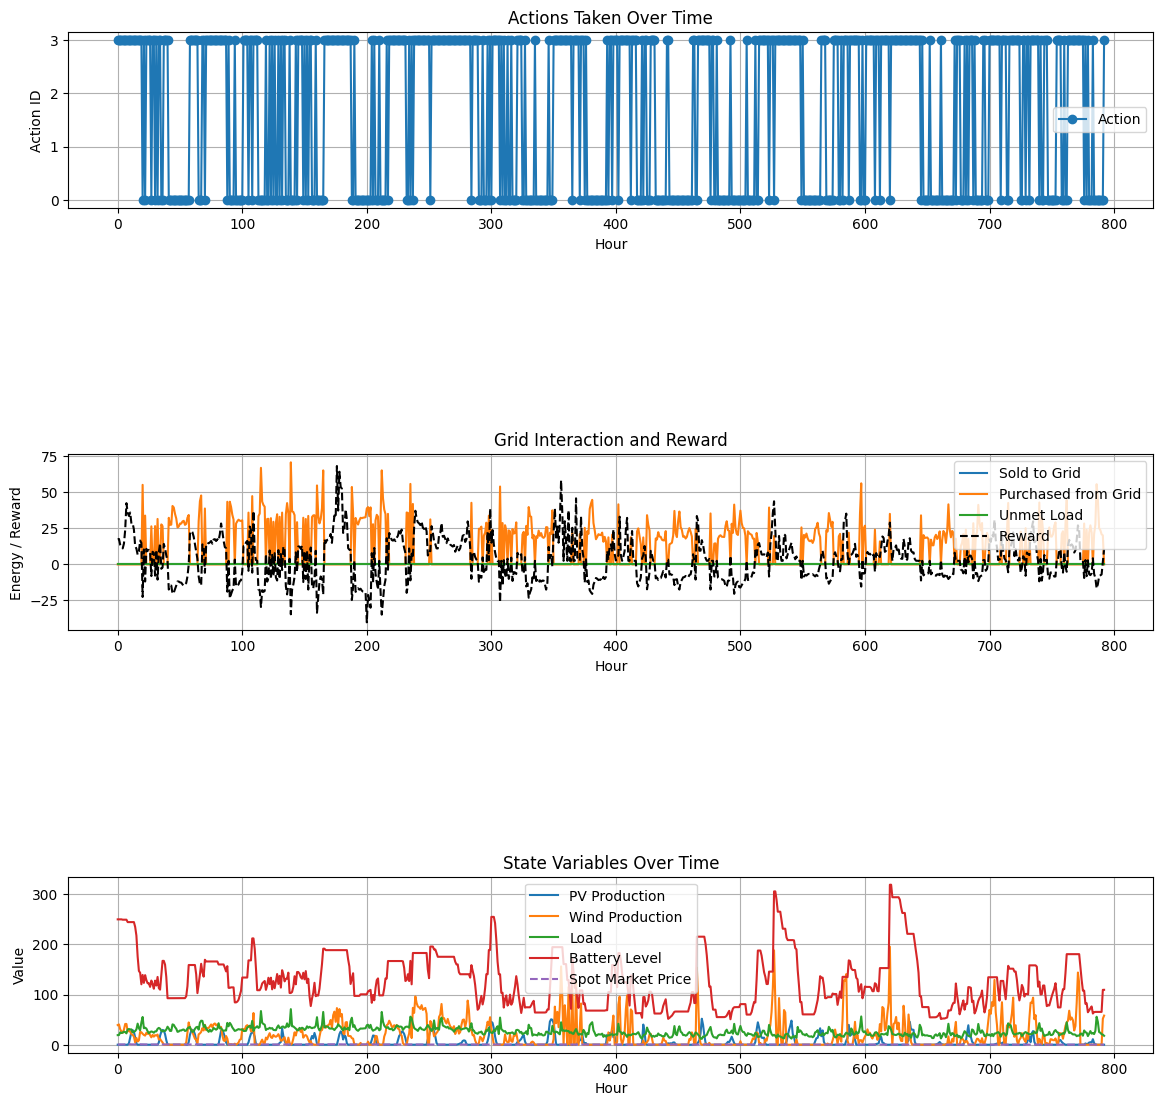

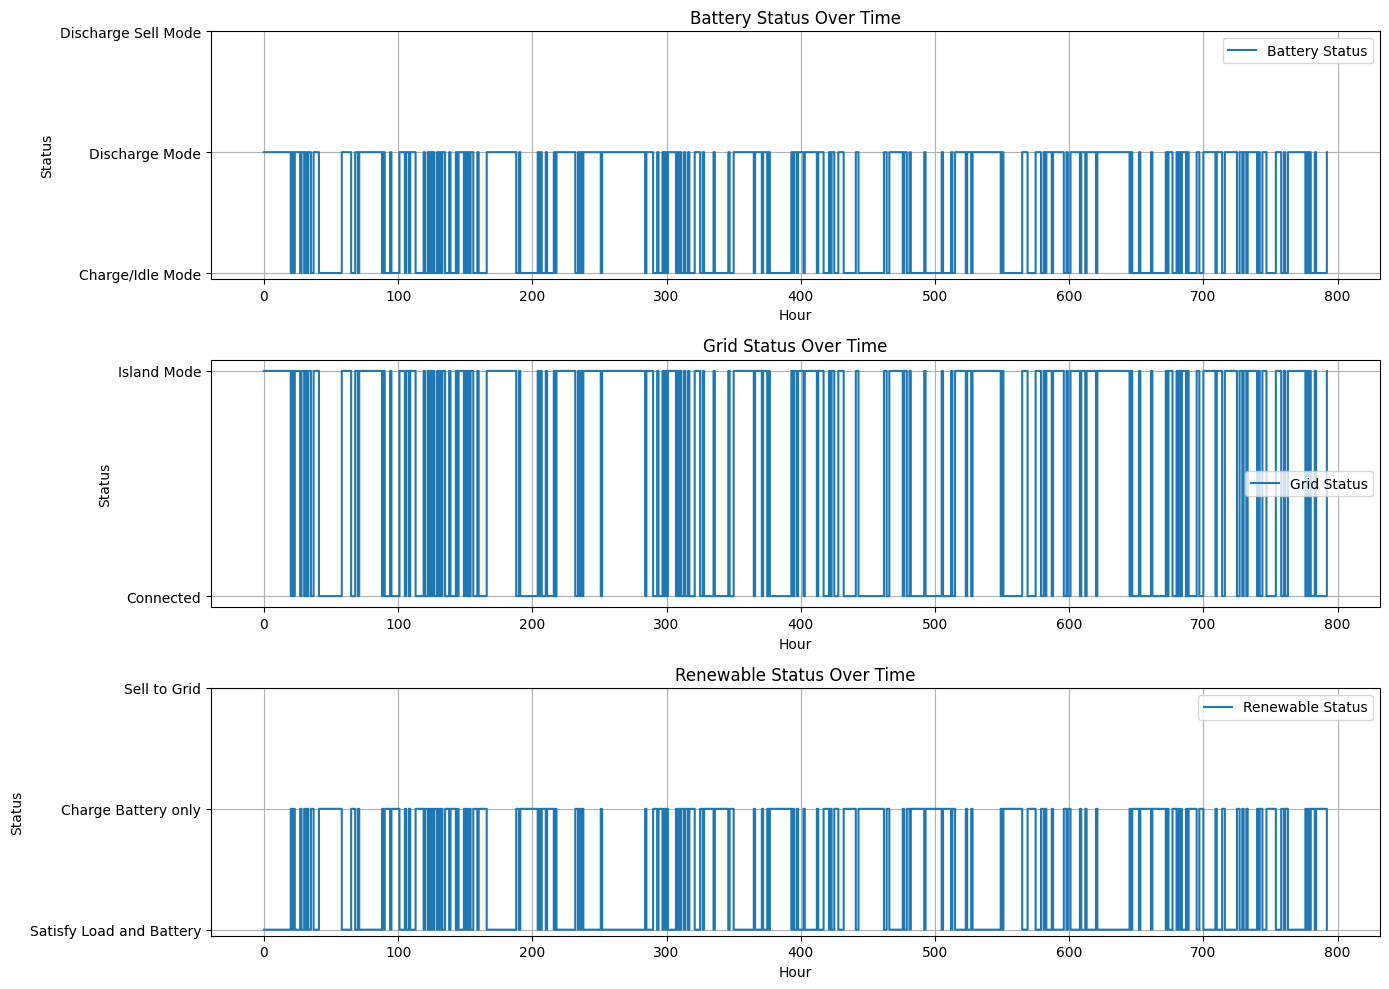

1. % of Load Met with Purchased Energy: 45.29%
2. % of Time Grid in Island Mode: 56.12%
3. Total Purchased Energy Cost: 3859.54 (NOK)


In [69]:
test_simulate_and_plot(env_2, model, 34)